# Описание проекта

Вы — специалист по Data Science в каршеринговой компании. Вам поступил заказ: нужно создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.<br>

Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует. Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.<br>

Идея решения задачи от заказчика: 
1. Создать модель предсказания ДТП (целевое значение — at_fault (виновник) в таблице parties)
    * Для модели выбрать тип виновника — только машина (car).
    * Выбрать случаи, когда ДТП привело к любым повреждениям транспортного средства, кроме типа SCRATCH (царапина).
    * Для моделирования ограничиться данными за 2012 год — они самые свежие.
    * Обязательное условие — учесть фактор возраста автомобиля.
2. На основе модели исследовать основные факторы ДТП.
3. Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы:
    * Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
    * Какие ещё факторы нужно учесть?
    * Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?<br>
    
Заказчик предлагает вам поработать с базой данных по происшествиям и сформировать свои идеи создания такой системы. 

## Подключимся к базе и загрузим таблицы sql

In [1]:
!pip install phik -q

In [2]:
!pip install category_encoders -q

In [3]:
!pip install shap -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

import phik
import shap

from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform, loguniform, randint, stats
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, mean_squared_error, roc_auc_score, log_loss, recall_score, confusion_matrix
from catboost import Pool

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [5]:
db_config = {
'user': 'praktikum_student', # имя пользователя,
'pwd': 'Sdf4$2;d-d30pp', # пароль,
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432, # порт подключения,
'db': 'data-science-vehicle-db' # название базы данных,
}

In [6]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [7]:
engine = create_engine(connection_string)

## Проведем первичное исследование таблиц

In [8]:
query = '''
SELECT *
FROM case_ids
LIMIT 5
'''
df = pd.read_sql_query(query, con = engine)
df

,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   case_id  5 non-null      object
 1   db_year  5 non-null      object
dtypes: object(2)
memory usage: 208.0+ bytes


In [10]:
df['db_year'].unique()

array(['2021'], dtype=object)

In [11]:
query = '''
SELECT *
FROM vehicles
LIMIT 5
'''
df = pd.read_sql_query(query, con = engine)
df

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    5 non-null      int64 
 1   case_id               5 non-null      object
 2   party_number          5 non-null      int64 
 3   vehicle_type          5 non-null      object
 4   vehicle_transmission  5 non-null      object
 5   vehicle_age           5 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 368.0+ bytes


In [13]:
query = '''
SELECT *
FROM collisions
LIMIT 5
'''
df = pd.read_sql_query(query, con = engine)
df

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      5 non-null      object 
 1   county_city_location         5 non-null      object 
 2   county_location              5 non-null      object 
 3   distance                     5 non-null      float64
 4   direction                    1 non-null      object 
 5   intersection                 5 non-null      int64  
 6   weather_1                    5 non-null      object 
 7   location_type                1 non-null      object 
 8   collision_damage             5 non-null      object 
 9   party_count                  5 non-null      int64  
 10  primary_collision_factor     5 non-null      object 
 11  pcf_violation_category       5 non-null      object 
 12  type_of_collision            5 non-null      object 
 13  motor_vehicle_involved_w

In [15]:
query = '''
SELECT *
FROM parties
LIMIT 5
'''
df = pd.read_sql_query(query, con = engine)
df

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,None,0
1,23,3899454,2,road signs,0,7.0,had not been drinking,None,0
2,29,3899462,2,car,0,21.0,had not been drinking,None,0
3,31,3899465,2,road signs,0,24.0,had not been drinking,None,0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5 non-null      int64  
 1   case_id              5 non-null      object 
 2   party_number         5 non-null      int64  
 3   party_type           5 non-null      object 
 4   at_fault             5 non-null      int64  
 5   insurance_premium    4 non-null      float64
 6   party_sobriety       5 non-null      object 
 7   party_drug_physical  1 non-null      object 
 8   cellphone_in_use     5 non-null      int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 488.0+ bytes


### Промежуточный вывод

* данные загружены (для экономии памяти сделаны срезы первых 5 строк)
* все таблицы имеют набор данных
* данные в таблицах удовлетворяют условию задачи
* имеется общий ключ для связи всех таблиц

##  Проведем статистический анализ факторов ДТП

### Выясним, в какие месяцы происходит наибольшее количество аварий. Проанализируем весь период наблюдений (таблица collisions)

In [17]:
query = '''
SELECT COUNT(case_id) AS cnt,
       EXTRACT(MONTH FROM collision_date::date) AS dm
FROM collisions
GROUP BY dm
ORDER BY cnt DESC
'''
df = pd.read_sql_query(query, con = engine)
df

,cnt,dm
0,139581,3.0
1,132044,1.0
2,130316,5.0
3,130180,4.0
4,128858,2.0
5,112237,10.0
6,107945,12.0
7,105159,9.0
8,104770,11.0
9,104089,8.0


Проверим полноту данных по годам.

In [18]:
query = '''
SELECT 
    EXTRACT(YEAR FROM collision_date::date) AS year,
    COUNT(DISTINCT EXTRACT(MONTH FROM collision_date::date)) AS months_available,
    COUNT(case_id) AS total_accidents,
    MIN(collision_date::date) AS first_date,
    MAX(collision_date::date) AS last_date
FROM collisions
WHERE collision_date IS NOT NULL
GROUP BY EXTRACT(YEAR FROM collision_date::date)
ORDER BY year
'''
df = pd.read_sql_query(query, con = engine)
df

,year,months_available,total_accidents,first_date,last_date
0,2009.0,12,426228,2009-01-01,2009-12-31
1,2010.0,12,416490,2010-01-01,2010-12-31
2,2011.0,12,402428,2011-01-01,2011-12-31
3,2012.0,12,154547,2012-01-01,2012-12-31
4,2013.0,6,305,2013-01-01,2013-07-08
5,2020.0,2,2,2020-03-14,2020-07-26


С 2009 по 2012 года данные по всем месяцам в отличие от 2013 и 2020, исключим их при анализе статистики.

В 2012 году в 2,5 раза меньше данных, посмотрим на этот год по месяцам

In [19]:
query = '''
SELECT COUNT(case_id) AS cnt,
       EXTRACT(MONTH FROM collision_date::date) AS dm
FROM collisions
WHERE EXTRACT(YEAR FROM collision_date::date) = 2012
GROUP BY dm
ORDER BY dm
'''
df = pd.read_sql_query(query, con = engine)
df

,cnt,dm
0,32020,1.0
1,30377,2.0
2,32498,3.0
3,29143,4.0
4,25168,5.0
5,3062,6.0
6,390,7.0
7,622,8.0
8,510,9.0
9,304,10.0


как видно, данные за 2012 год начиная с мая месяца не полные. Учтем это в дальнейшем

Проанализируем количество аварий по месяцам за весь период до 2011 года включительно

In [20]:
query = '''
SELECT COUNT(case_id) AS cnt,
       EXTRACT(MONTH FROM collision_date::date) AS dm
FROM collisions
WHERE EXTRACT(YEAR FROM collision_date::date) < 2012
GROUP BY dm
ORDER BY dm
'''
df = pd.read_sql_query(query, con = engine)
df

,cnt,dm
0,99880,1.0
1,98373,2.0
2,107036,3.0
3,101032,4.0
4,105148,5.0
5,99531,6.0
6,101835,7.0
7,103467,8.0
8,104649,9.0
9,111933,10.0


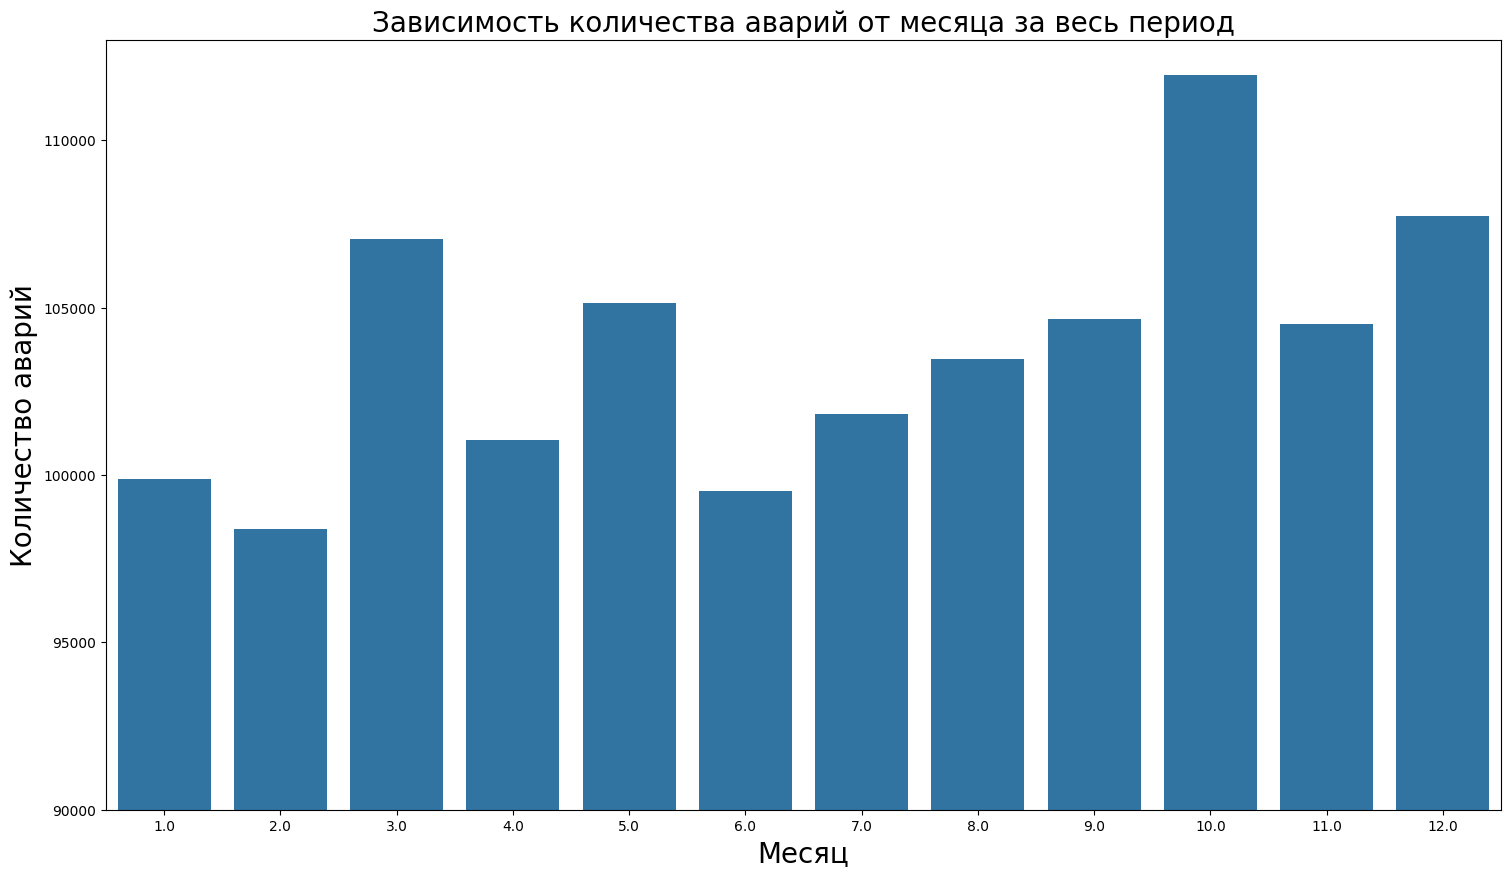

In [21]:
fig = plt.figure(figsize=(18, 10))
sns.barplot(data=df, x='dm', y='cnt')
plt.title('Зависимость количества аварий от месяца за весь период', size=20)
plt.ylabel('Количество аварий', size=20)
plt.xlabel('Месяц', size=20)
plt.ylim(90000, 113000)
plt.show()

Судя про барам, самые аварийные месяцы за весь период наблюдений в предоставленных данных это октябрь, декабрь и март.<br>
Март и октябрь - пограничные месяца перехода весенне-осеннего периода, когда знакопеременная температура постоянно меняет условия на дорожном покрытии. Водители еще не успели перестроится в новых условиях управления транспортом.
Последний месяц весны является также не менее опасным в следствии увеличения средней скорости движения на доррогах в начальный летний период.

### Создадим не менее шести задач для коллег.

* проанализировать наибольшее количетсво аварий, в какие часы, в 24 часовом формате за весь период, происходит наибольшее количество аварий
* проанализировать серьёзности повреждений транспортного средства, исходя из возраста автомобиля
* проанализировать сумму старховок по месяцам за весь период
* проанализировать наибольшее количество авраий в завиисмости от типа КПП
* проанализировать наибольшее количество авраий в завиисмости от дорожного состояния
* проанализировать серъезность повреждений транспортного средства в зависимости от трезвости участника

Для решения использовать следующий порядок:
* Создайте sql-запрос;
* Постройте график;
* Сделайте вывод.

### Проанализируем серьёзность повреждений транспортного средства, исходя из возраста автомобиля

In [22]:
query = '''
SELECT CASE 
            WHEN v.vehicle_age <= 3 THEN '1. 0 - 3 года'
            WHEN v.vehicle_age <= 7 THEN '2. 4 - 7 лет'
            WHEN v.vehicle_age <= 15 THEN '3. 8 - 15 лет'
            ELSE '4. 15 + лет'
       END AS age_group,
    c.collision_damage,
    COUNT(*) AS cnt_d
FROM collisions AS c
JOIN vehicles AS v ON c.case_id=v.case_id
GROUP BY age_group, c.collision_damage
ORDER BY age_group, cnt_d DESC
'''
df = pd.read_sql_query(query, con = engine)
df.head(10)

,age_group,collision_damage,cnt_d
0,1. 0 - 3 года,small damage,135934
1,1. 0 - 3 года,scratch,134039
2,1. 0 - 3 года,middle damage,79964
3,1. 0 - 3 года,severe damage,12950
4,1. 0 - 3 года,fatal,3762
5,2. 4 - 7 лет,scratch,197915
6,2. 4 - 7 лет,small damage,90116
7,2. 4 - 7 лет,middle damage,87891
8,2. 4 - 7 лет,severe damage,17181
9,2. 4 - 7 лет,fatal,6048


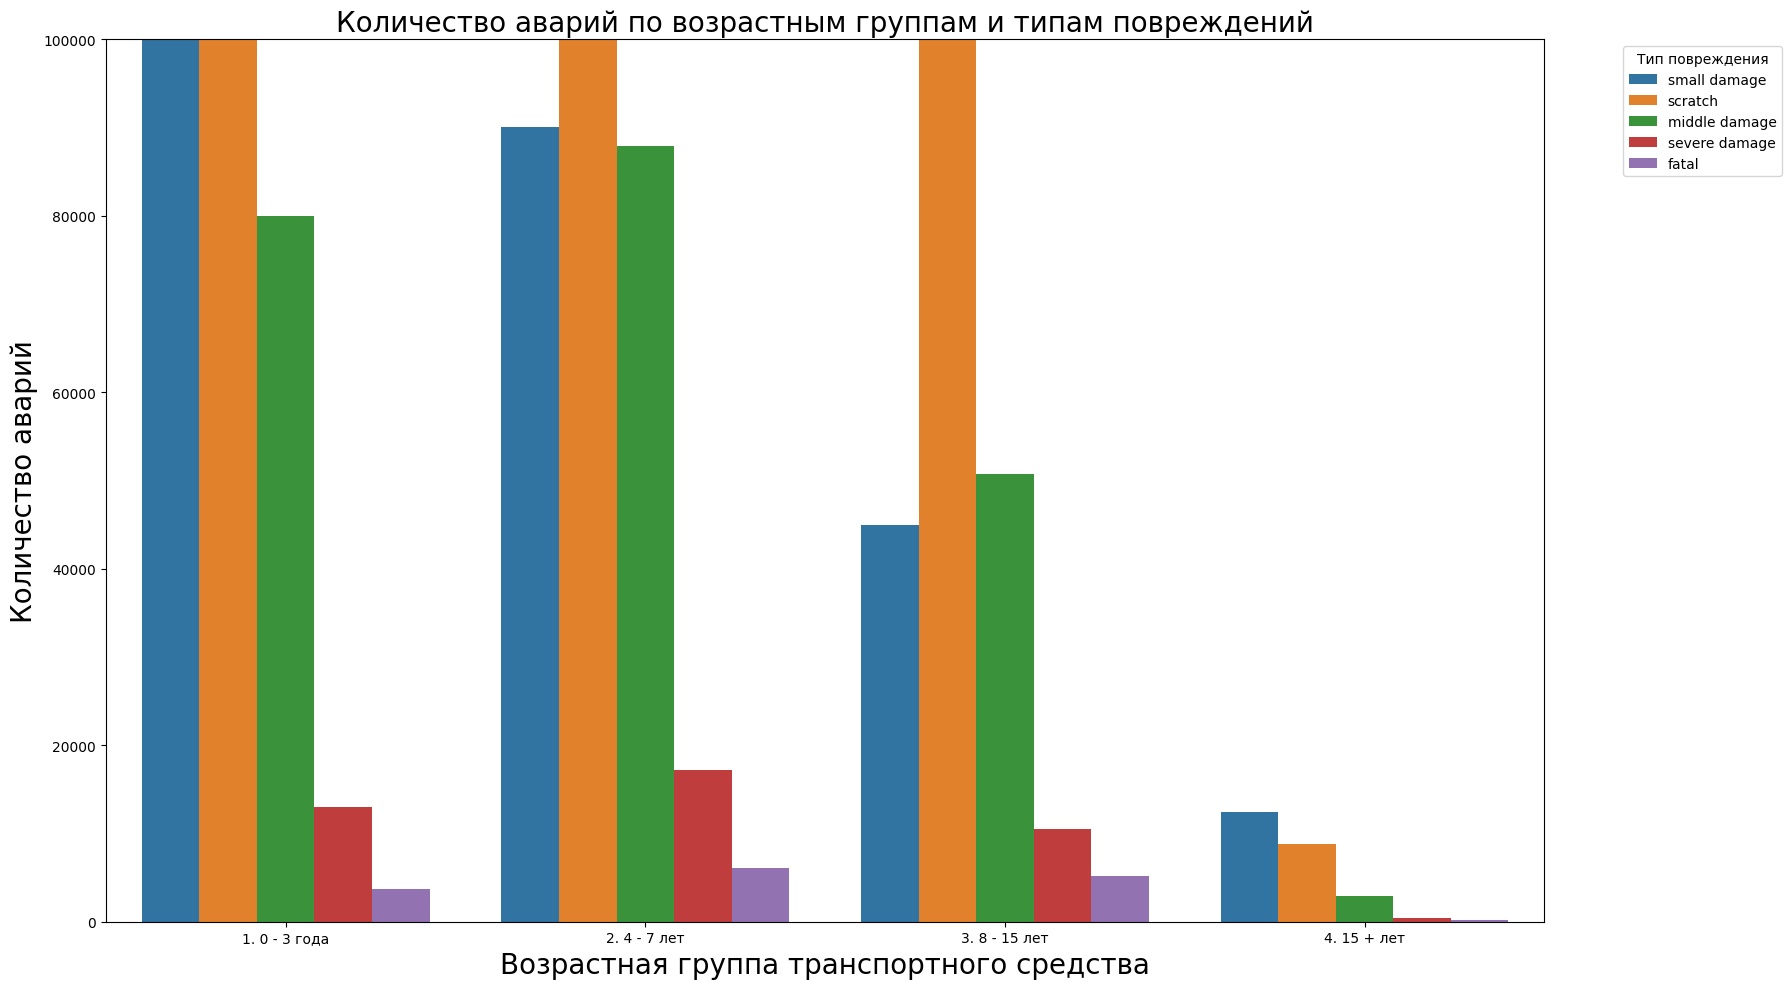

In [23]:
fig = plt.figure(figsize=(18, 10))
sns.barplot(data=df, x='age_group', y='cnt_d', hue='collision_damage')
plt.title('Количество аварий по возрастным группам и типам повреждений', size=20)
plt.xlabel('Возрастная группа транспортного средства', size=20)  
plt.ylabel('Количество аварий', size=20)  
plt.legend(title='Тип повреждения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.ylim(0, 100000)
plt.show()

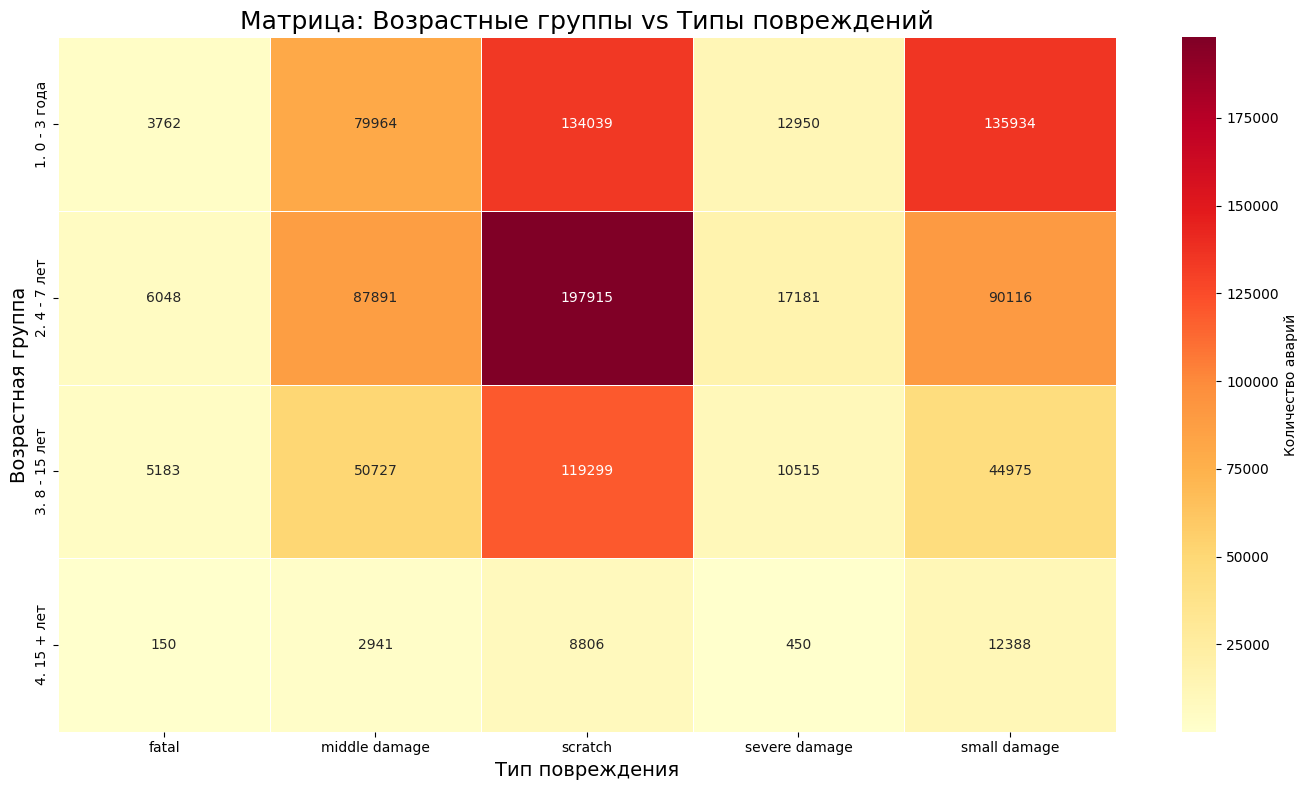

In [24]:
pivot_table = df.pivot(index='age_group', 
                       columns='collision_damage', 
                       values='cnt_d')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Количество аварий'})
plt.title('Матрица: Возрастные группы vs Типы повреждений', size=18)
plt.xlabel('Тип повреждения', size=14)
plt.ylabel('Возрастная группа', size=14)
plt.tight_layout()
plt.show()

Если не учитывать царапины и малые повреждения:
* на первом месте по всем видам аварий (сильное повреждение, среденее и фатальное) наибольшее количество у возрастной группы от 4-7 лет, это скорее основная категория автолюбителей, предположим что их больше в выборке данных
* на втором и третьем месте находятся группы от 8-15 и от 0 до 3 лет соответственно
* и меньше всего ДТП у автомобилей возрастной группы 15+

### Проанализируем серьёзность повреждений транспортного средства в зависимости от трезвости участника

In [25]:
query = '''
SELECT CASE 
            WHEN p.party_sobriety = 'had not been drinking' THEN 'трезвый'
            WHEN p.party_sobriety IN ('had been drinking, under influence',
                                      'had been drinking, not under influence',
                                       'had been drinking, impairment unknown') THEN 'не трезвый'
            ELSE 'неизвестно'
       END AS drink_group,
    c.collision_damage,
    COUNT(*) AS cnt_d
FROM collisions AS c
JOIN parties AS p ON c.case_id=p.case_id
GROUP BY drink_group, c.collision_damage
ORDER BY drink_group, cnt_d DESC
'''
df = pd.read_sql_query(query, con = engine)
df.head(10)

,drink_group,collision_damage,cnt_d
0,не трезвый,small damage,87228
1,не трезвый,middle damage,27876
2,не трезвый,scratch,23937
3,не трезвый,severe damage,7956
4,не трезвый,fatal,4485
5,неизвестно,small damage,353298
6,неизвестно,scratch,71650
7,неизвестно,middle damage,39193
8,неизвестно,severe damage,8852
9,неизвестно,fatal,3206


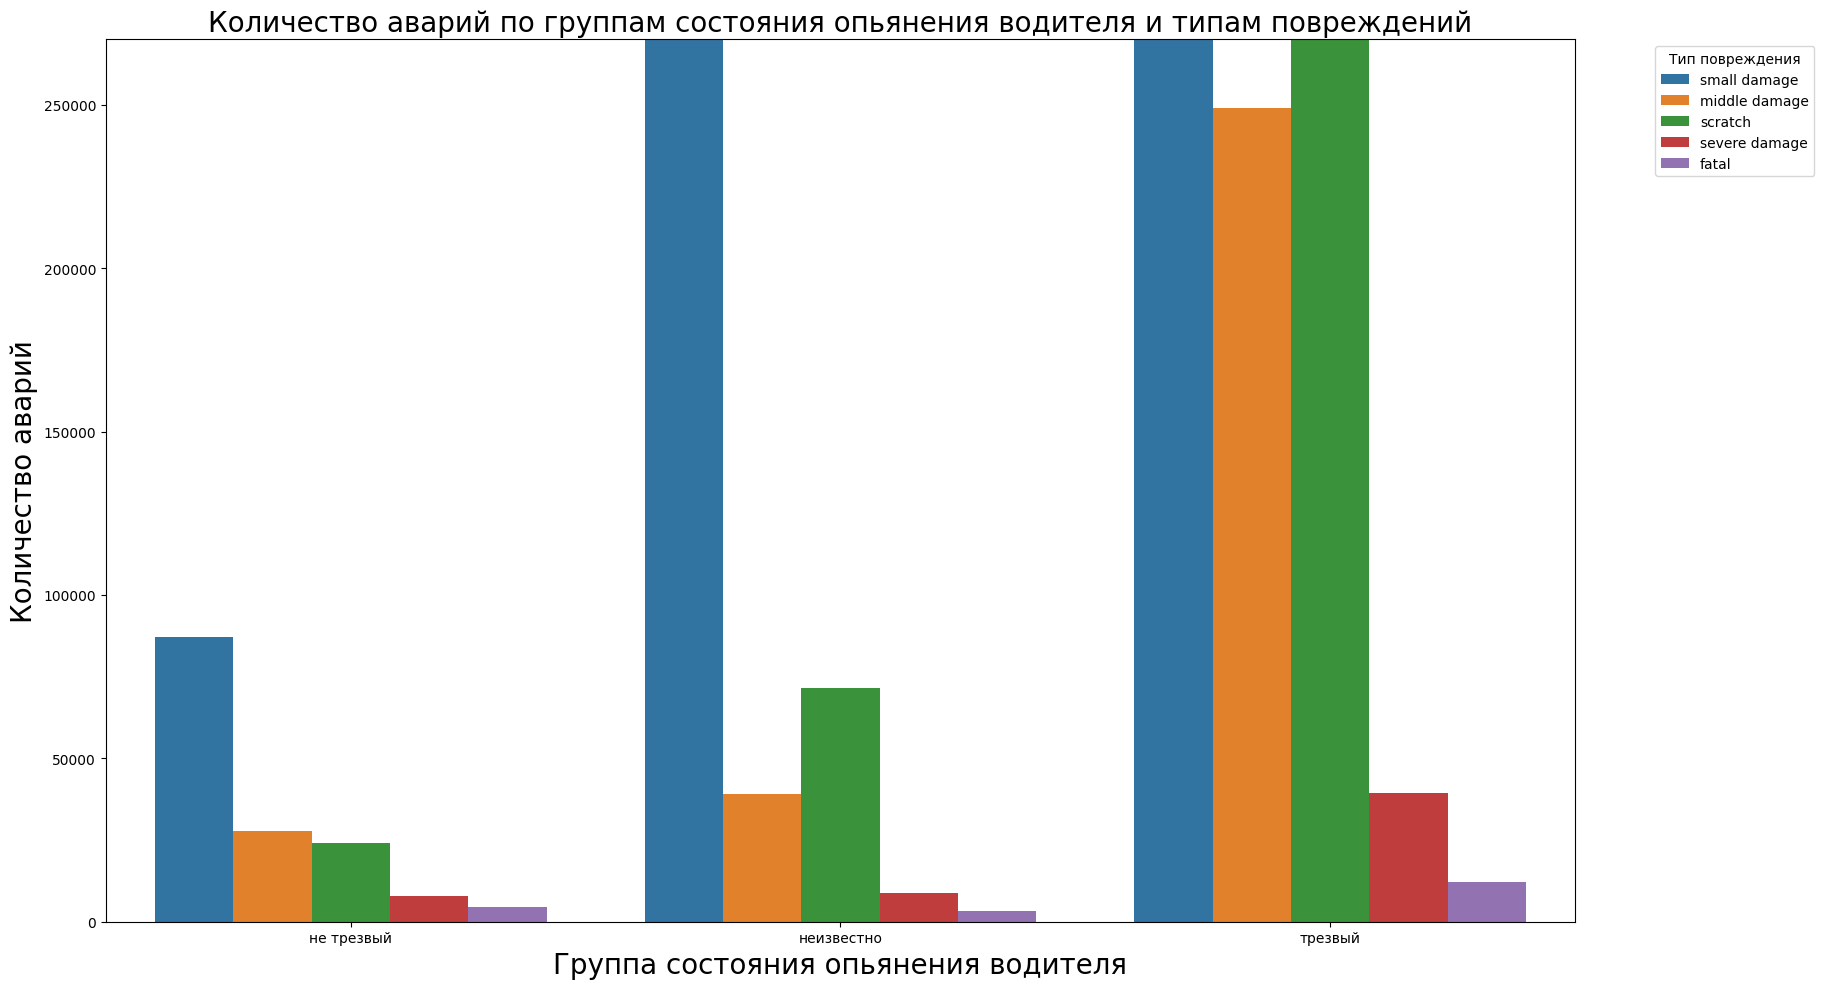

In [26]:
fig = plt.figure(figsize=(18, 10))
sns.barplot(data=df, x='drink_group', y='cnt_d', hue='collision_damage')
plt.title('Количество аварий по группам состояния опьянения водителя и типам повреждений', size=20)
plt.xlabel('Группа состояния опьянения водителя', size=20)  
plt.ylabel('Количество аварий', size=20)  
plt.legend(title='Тип повреждения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.ylim(0, 270000)
plt.show()

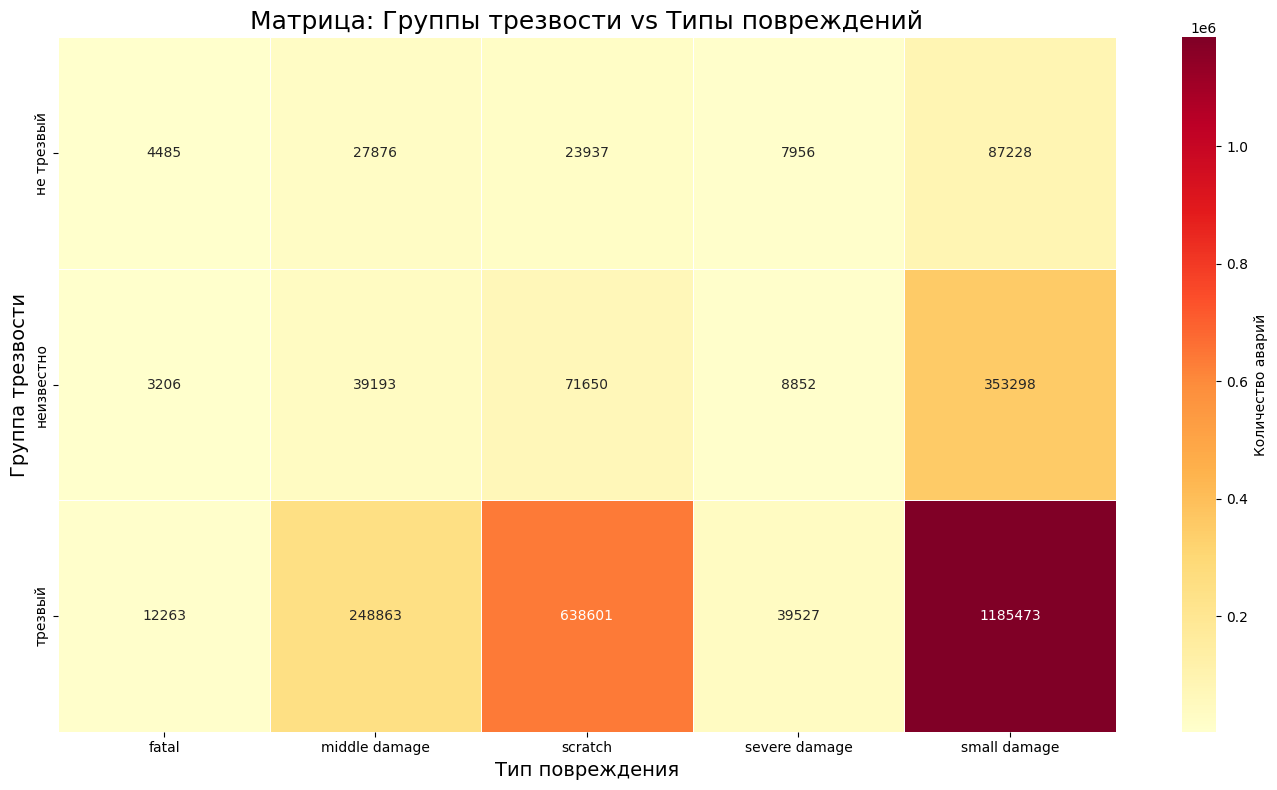

In [27]:
pivot_table = df.pivot(index='drink_group', 
                       columns='collision_damage', 
                       values='cnt_d')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Количество аварий'})
plt.title('Матрица: Группы трезвости vs Типы повреждений', size=18)
plt.xlabel('Тип повреждения', size=14)
plt.ylabel('Группа трезвости', size=14)
plt.tight_layout()
plt.show()

* самая многочисленная группа - трезвый водитель, и по количествам ДТП и по фатальным последствиям для транспортного средства
Тут есть вопрос к количеству в выборке трезвых и не трезвых водителей.

## Создадим модель для оценки водительского риска

### Подготовим набор данных на основе первичного предположения заказчика

In [28]:
query = '''
SELECT *
FROM collisions c
JOIN parties p USING (case_id)  
JOIN vehicles v USING (case_id, party_number) 
WHERE EXTRACT(YEAR FROM c.collision_date::date) = 2012
    AND c.collision_damage != 'scratch'
    AND p.party_type = 'car'
'''
df = pd.read_sql_query(query, con = engine)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      56248 non-null  object 
 1   party_number                 56248 non-null  int64  
 2   county_city_location         56248 non-null  object 
 3   county_location              56248 non-null  object 
 4   distance                     56248 non-null  float64
 5   direction                    43230 non-null  object 
 6   intersection                 56073 non-null  float64
 7   weather_1                    56080 non-null  object 
 8   location_type                25932 non-null  object 
 9   collision_damage             56248 non-null  object 
 10  party_count                  56248 non-null  int64  
 11  primary_collision_factor     56137 non-null  object 
 12  pcf_violation_category       55482 non-null  object 
 13  type_of_collisio

Удалим столбцы **'id'**

In [29]:
df = df.drop('id', axis=1)
df.head()

,case_id,party_number,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,...,collision_time,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age
0,5454402,1,3711,san diego,1500.0,south,0.0,clear,highway,middle damage,...,01:50:00,car,1,NaN,impairment unknown,G,0.0,sedan,manual,3.0
1,5612084,2,3600,san bernardino,40.0,north,0.0,cloudy,None,small damage,...,17:40:00,car,0,34.0,had not been drinking,None,0.0,sedan,auto,0.0
2,5618760,2,1949,los angeles,150.0,south,0.0,clear,highway,small damage,...,09:15:00,car,0,18.0,had not been drinking,None,0.0,sedan,auto,4.0
3,5618865,1,1900,los angeles,137.0,east,0.0,raining,None,small damage,...,11:55:00,car,1,32.0,had not been drinking,None,0.0,sedan,auto,6.0
4,5627308,2,3400,sacramento,150.0,south,0.0,clear,None,small damage,...,12:00:00,car,0,51.0,had not been drinking,None,0.0,sedan,auto,0.0


### Проведем первичный отбор факторов, необходимых для модели.

In [30]:
columns = ['insurance_premium',    # Сумма страховки (тыс. $) Таблица Parties
           'at_fault',             # Таргет Таблица collisions
           'county_city_location', # Номер географических районов, где произошло ДТП. Таблица collisions
           'vehicle_type',         # Тип кузова. Таблица vehicles
           'vehicle_transmission', # Тип кпп. Таблица vehicles
           'vehicle_age',          # Возраст автомобиля (как видно из графика выше, имеется зависимость) Таблица vehicles
           'county_location',      # Названия географических районов, где произошло ДТП. Таблица collisions
           'intersection',         # Является ли место происшествия перекрёстком. Таблица collisions
           'weather_1',            # Погода. Таблица collisions
           'road_surface',         # Состояние дороги. Таблица collisions
           'road_condition_1',     # Дорожное состояние. Таблица collisions
           'lighting',             # Освещение. Таблица collisions
           'collision_date',       # Дата происшествия. Таблица collisions
           'collision_time',       # Время происшествия. Таблица collisions
           'cellphone_in_use'      # Наличие телефона в автомобиле (возможности разговаривать по громкой связи) Таблица Parties
         ]

Не используем признаки, которые стали известны после аварии

Данные признаки наиболее явно отражают возможное влияние на вероятность ДТП

In [31]:
data = df[columns].copy()
data.head()

,insurance_premium,at_fault,county_city_location,vehicle_type,vehicle_transmission,vehicle_age,county_location,intersection,weather_1,road_surface,road_condition_1,lighting,collision_date,collision_time,cellphone_in_use
0,NaN,1,3711,sedan,manual,3.0,san diego,0.0,clear,dry,normal,dark with street lights,2012-01-20,01:50:00,0.0
1,34.0,0,3600,sedan,auto,0.0,san bernardino,0.0,cloudy,dry,normal,daylight,2012-05-02,17:40:00,0.0
2,18.0,0,1949,sedan,auto,4.0,los angeles,0.0,clear,dry,normal,daylight,2012-05-10,09:15:00,0.0
3,32.0,1,1900,sedan,auto,6.0,los angeles,0.0,raining,wet,normal,daylight,2012-04-13,11:55:00,0.0
4,51.0,0,3400,sedan,auto,0.0,sacramento,0.0,clear,dry,normal,daylight,2012-04-09,12:00:00,0.0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   insurance_premium     55701 non-null  float64
 1   at_fault              56248 non-null  int64  
 2   county_city_location  56248 non-null  object 
 3   vehicle_type          56248 non-null  object 
 4   vehicle_transmission  55389 non-null  object 
 5   vehicle_age           54554 non-null  float64
 6   county_location       56248 non-null  object 
 7   intersection          56073 non-null  float64
 8   weather_1             56080 non-null  object 
 9   road_surface          55900 non-null  object 
 10  road_condition_1      55999 non-null  object 
 11  lighting              56094 non-null  object 
 12  collision_date        56248 non-null  object 
 13  collision_time        56160 non-null  object 
 14  cellphone_in_use      51777 non-null  float64
dtypes: float64(4), int6

Переведем **collision_date и collision_time** к типу дата. А также добавим из признака дата еще признаки, разделенные на месяцы и дни. Это может быть полезно для модели.

In [33]:
data['collision_date'] = pd.to_datetime(data['collision_date'])
data['collision_time'] = pd.to_datetime(data['collision_time'], format='%H:%M:%S').dt.time
data['month'] = data['collision_date'].dt.month
data['dayofweek'] = data['collision_date'].dt.dayofweek  # 0=Понедельник, 6=Воскресенье

In [34]:
data.head()

,insurance_premium,at_fault,county_city_location,vehicle_type,vehicle_transmission,vehicle_age,county_location,intersection,weather_1,road_surface,road_condition_1,lighting,collision_date,collision_time,cellphone_in_use,month,dayofweek
0,NaN,1,3711,sedan,manual,3.0,san diego,0.0,clear,dry,normal,dark with street lights,2012-01-20,01:50:00,0.0,1,4
1,34.0,0,3600,sedan,auto,0.0,san bernardino,0.0,cloudy,dry,normal,daylight,2012-05-02,17:40:00,0.0,5,2
2,18.0,0,1949,sedan,auto,4.0,los angeles,0.0,clear,dry,normal,daylight,2012-05-10,09:15:00,0.0,5,3
3,32.0,1,1900,sedan,auto,6.0,los angeles,0.0,raining,wet,normal,daylight,2012-04-13,11:55:00,0.0,4,4
4,51.0,0,3400,sedan,auto,0.0,sacramento,0.0,clear,dry,normal,daylight,2012-04-09,12:00:00,0.0,4,0


Проверим на пропуски наши данные

In [35]:
data.isnull().sum()

insurance_premium        547
at_fault                   0
county_city_location       0
vehicle_type               0
vehicle_transmission     859
vehicle_age             1694
county_location            0
intersection             175
weather_1                168
road_surface             348
road_condition_1         249
lighting                 154
collision_date             0
collision_time            88
cellphone_in_use        4471
month                      0
dayofweek                  0
dtype: int64

Колонки с минимальными пропусками (<=1.0%) - удалим пропуски, так как они составляют малое количество от всей выборки данных.

In [36]:
data = data.dropna(subset=['insurance_premium',
    'intersection', 'weather_1', 'road_surface',
    'road_condition_1', 'lighting', 'collision_time'
    ])

In [37]:
data.isnull().sum()

insurance_premium          0
at_fault                   0
county_city_location       0
vehicle_type               0
vehicle_transmission     822
vehicle_age             1527
county_location            0
intersection               0
weather_1                  0
road_surface               0
road_condition_1           0
lighting                   0
collision_date             0
collision_time             0
cellphone_in_use        4091
month                      0
dayofweek                  0
dtype: int64

In [38]:
data['intersection'].value_counts()

0.0    42675
1.0    12061
Name: intersection, dtype: int64

Приведем признак **`intersection`** к типу INT

In [39]:
data['intersection'] = data['intersection'].astype(int)
data['intersection'].value_counts()

0    42675
1    12061
Name: intersection, dtype: int64

In [40]:
data.shape

(54736, 17)

Для оставшихся пропусков используем разные стратегии по их заполнению. <br>
* для признака **`vehicle_transmission`** выберем заполнение пропусков модой.`<br>

In [41]:
mode_transmission = data['vehicle_transmission'].mode()[0]
data['vehicle_transmission'] = data['vehicle_transmission'].fillna(mode_transmission)

Удалим автомобили старше 10 лет, так как их не рентабельно использовать в каршеринге.

In [42]:
data = data[data['vehicle_age'] <= 10]

In [43]:
data.isnull().sum()

insurance_premium          0
at_fault                   0
county_city_location       0
vehicle_type               0
vehicle_transmission       0
vehicle_age                0
county_location            0
intersection               0
weather_1                  0
road_surface               0
road_condition_1           0
lighting                   0
collision_date             0
collision_time             0
cellphone_in_use        3618
month                      0
dayofweek                  0
dtype: int64

Заполним пропуски в колонке cellphone_in_use на категорию 'Unknown'. Это позволит нам сохранить данные, и убрать пропуски которые губительны для будущих моделей.

In [44]:
data['cellphone_in_use'] = data['cellphone_in_use'].fillna('unknown')

In [45]:
data.isnull().sum()

insurance_premium       0
at_fault                0
county_city_location    0
vehicle_type            0
vehicle_transmission    0
vehicle_age             0
county_location         0
intersection            0
weather_1               0
road_surface            0
road_condition_1        0
lighting                0
collision_date          0
collision_time          0
cellphone_in_use        0
month                   0
dayofweek               0
dtype: int64

Проверим наши данные на явные дубликаты, при наличии удалим их.

In [46]:
data.duplicated().sum()

19

In [47]:
data = data.drop_duplicates()
data.duplicated().sum()

0

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50117 entries, 1 to 56247
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   insurance_premium     50117 non-null  float64       
 1   at_fault              50117 non-null  int64         
 2   county_city_location  50117 non-null  object        
 3   vehicle_type          50117 non-null  object        
 4   vehicle_transmission  50117 non-null  object        
 5   vehicle_age           50117 non-null  float64       
 6   county_location       50117 non-null  object        
 7   intersection          50117 non-null  int32         
 8   weather_1             50117 non-null  object        
 9   road_surface          50117 non-null  object        
 10  road_condition_1      50117 non-null  object        
 11  lighting              50117 non-null  object        
 12  collision_date        50117 non-null  datetime64[ns]
 13  collision_time  

### Проведем статистическое исследование отобранных факторов.

In [49]:
data.describe()

,insurance_premium,at_fault,vehicle_age,intersection,month,dayofweek
count,50117.000000,50117.000000,50117.000000,50117.000000,50117.000000,50117.000000
mean,35.699902,0.502983,4.419977,0.213680,3.235050,3.172017
std,14.312622,0.499996,2.611647,0.409908,1.799586,1.969265
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,23.000000,0.000000,3.000000,0.000000,2.000000,1.000000
50%,33.000000,1.000000,4.000000,0.000000,3.000000,3.000000
75%,46.000000,1.000000,6.000000,0.000000,4.000000,5.000000
max,105.000000,1.000000,10.000000,1.000000,12.000000,6.000000


Категориальные признаки

In [50]:
data.head(2)

,insurance_premium,at_fault,county_city_location,vehicle_type,vehicle_transmission,vehicle_age,county_location,intersection,weather_1,road_surface,road_condition_1,lighting,collision_date,collision_time,cellphone_in_use,month,dayofweek
1,34.0,0,3600,sedan,auto,0.0,san bernardino,0,cloudy,dry,normal,daylight,2012-05-02,17:40:00,0.0,5,2
2,18.0,0,1949,sedan,auto,4.0,los angeles,0,clear,dry,normal,daylight,2012-05-10,09:15:00,0.0,5,3


In [51]:
categorial = ['at_fault', 'county_city_location', 'vehicle_type', 'vehicle_transmission',
              'county_location', 'intersection', 'weather_1',
              'road_surface', 'road_condition_1', 'lighting', 'cellphone_in_use']
for col in categorial:
    print(f'\n{col}:')
    print(data[col].value_counts(normalize=True).head())


at_fault:
1    0.502983
0    0.497017
Name: at_fault, dtype: float64

county_city_location:
1942    0.124828
1900    0.041124
3711    0.023685
3400    0.019973
3600    0.018776
Name: county_city_location, dtype: float64

vehicle_type:
sedan    0.656065
coupe    0.343895
other    0.000040
Name: vehicle_type, dtype: float64

vehicle_transmission:
manual    0.538919
auto      0.461081
Name: vehicle_transmission, dtype: float64

county_location:
los angeles       0.290999
orange            0.093142
san bernardino    0.067023
san diego         0.066704
riverside         0.057745
Name: county_location, dtype: float64

intersection:
0    0.78632
1    0.21368
Name: intersection, dtype: float64

weather_1:
clear      0.803061
cloudy     0.151106
raining    0.038929
fog        0.003292
snowing    0.002813
Name: weather_1, dtype: float64

road_surface:
dry         0.897739
wet         0.095058
snowy       0.006445
slippery    0.000758
Name: road_surface, dtype: float64

road_condition_1:
normal 

### Проведем корелляционный анализ данных и построим графики

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50117 entries, 1 to 56247
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   insurance_premium     50117 non-null  float64       
 1   at_fault              50117 non-null  int64         
 2   county_city_location  50117 non-null  object        
 3   vehicle_type          50117 non-null  object        
 4   vehicle_transmission  50117 non-null  object        
 5   vehicle_age           50117 non-null  float64       
 6   county_location       50117 non-null  object        
 7   intersection          50117 non-null  int32         
 8   weather_1             50117 non-null  object        
 9   road_surface          50117 non-null  object        
 10  road_condition_1      50117 non-null  object        
 11  lighting              50117 non-null  object        
 12  collision_date        50117 non-null  datetime64[ns]
 13  collision_time  

C:\Users\admin\.conda\envs\practicum\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable collision_time is large: 1433. Are you sure this is not an interval variable? Analysis for pairs of variables including collision_time can be slow.
  warnings.warn(


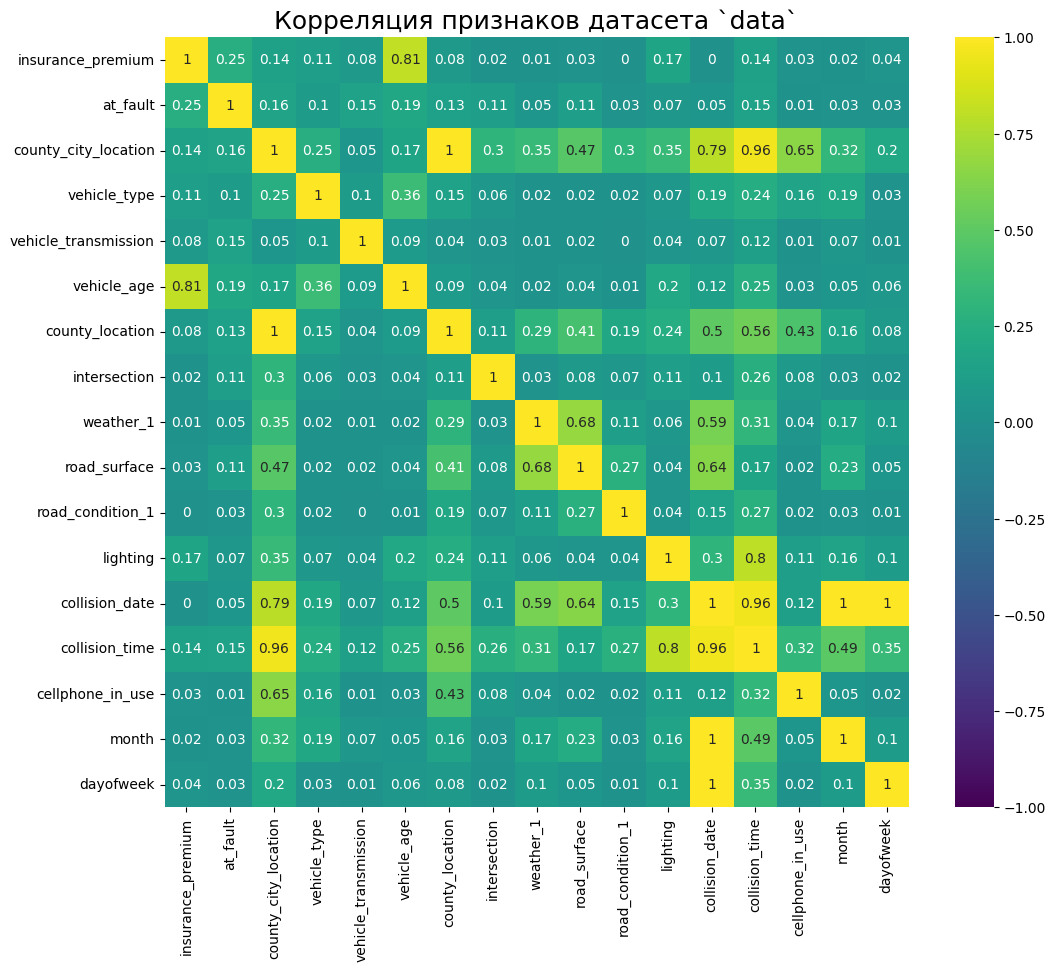

In [53]:
phi_corr = data.phik_matrix(interval_cols=['vehicle_age', 'insurance_premium']).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Корреляция признаков датасета `data`', size=18)
plt.show()

Наблюдается мульиколинераность по нескольким признакам:
* county_location vs county_city_location
* collision_time vs county_sity_location
* month vs collision_date          
* dayofweek vs collision_date

Оставим признак **`county_location`**, а **`county_city_location`** удалим
Также нам придется удалить признак **`collision_date`**, так как из него мы и создали два других **`month, dayofweek`**

C:\Users\admin\.conda\envs\practicum\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable collision_time is large: 1433. Are you sure this is not an interval variable? Analysis for pairs of variables including collision_time can be slow.
  warnings.warn(


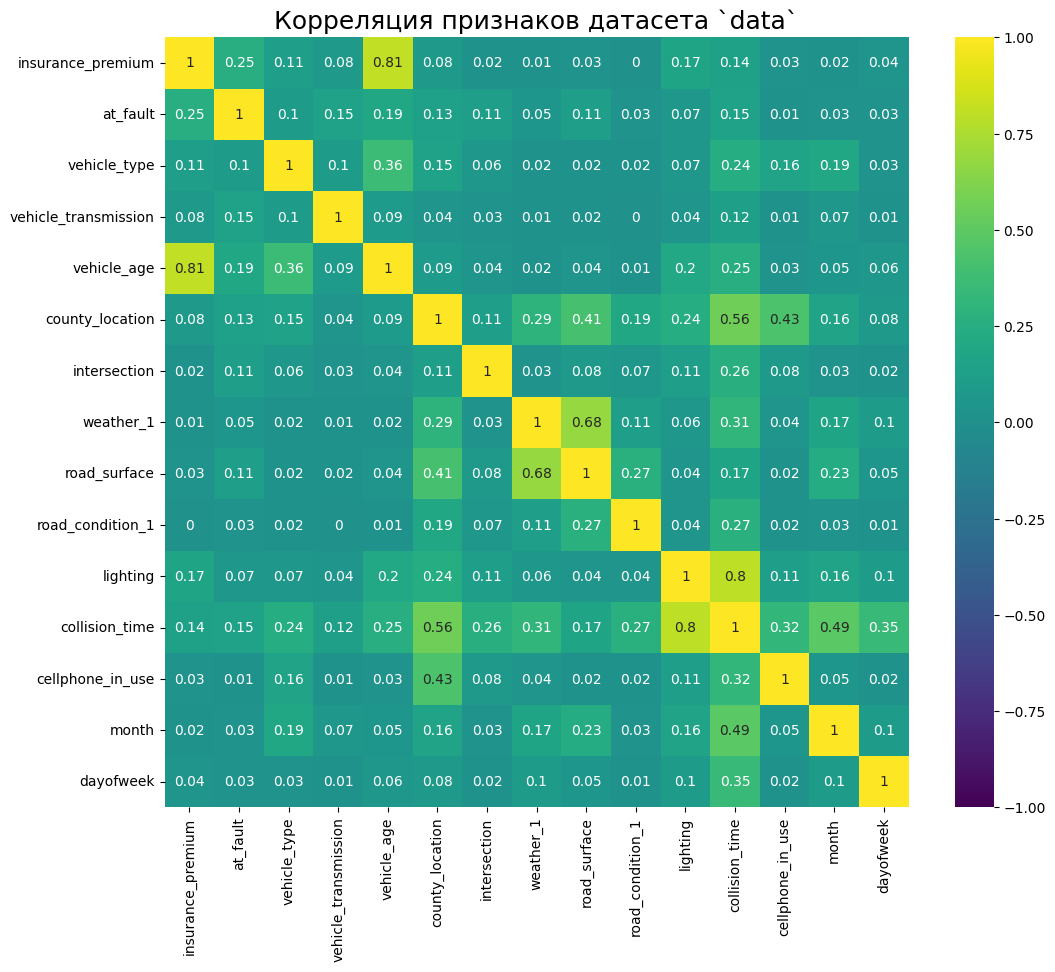

In [54]:
phi_corr = data.drop(columns=(['county_city_location', 'collision_date'])
                    ).phik_matrix(interval_cols=[
            'insurance_premium', 'vehicle_age']).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Корреляция признаков датасета `data`', size=18)
plt.show()

### Посмотрим на распределения признаков. 


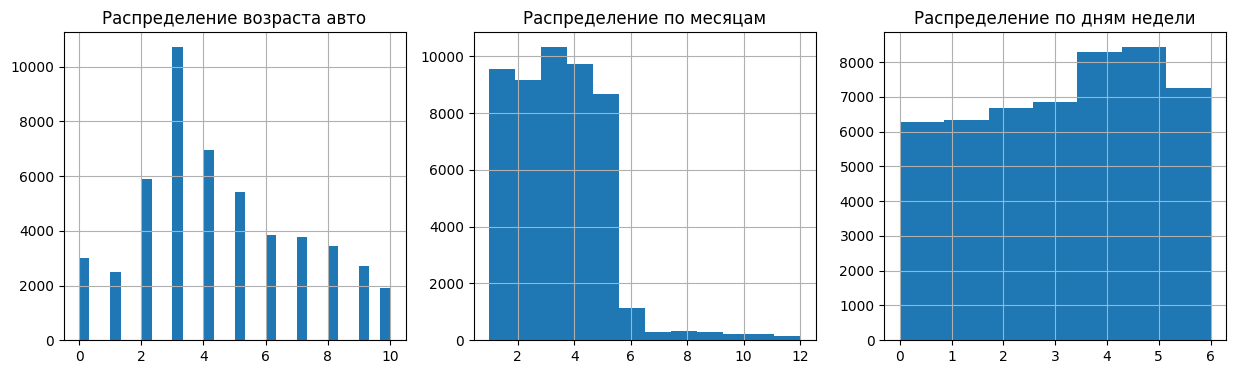

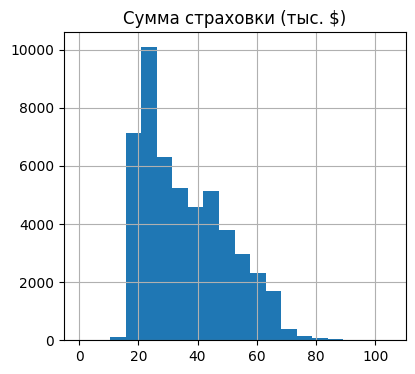

In [55]:
plt.figure(figsize=(15, 4))
plt.subplot(131)
data['vehicle_age'].hist(bins=30)
plt.title('Распределение возраста авто')

plt.subplot(132)
data['month'].hist(bins=12)
plt.title('Распределение по месяцам')

plt.subplot(133)
data['dayofweek'].hist(bins=7)
plt.title('Распределение по дням недели')
plt.show()

plt.figure(figsize=(15, 4))

plt.subplot(132)
data['insurance_premium'].hist(bins=20)
plt.title('Сумма страховки (тыс. $)')
plt.show()

Распределение возраста авто
* Пик приходится на возраст 3 ujlf - около 11,000 автомобилей. Быстрое убывание частоты с увеличением возраста. Основная масса автомобилей: 0-5 лет
* Большинство ДТП происходит с новыми автомобилями (0-3 года)
Возможныо это связано:
* Новые автомобили чаще находятся в активном использовании
* Водители новых авто могут быть менее опытными (первая машина)
* Или наоборот - новые авто чаще покупают активные водители

Распределение по месяцам
* Самые частые аварии наблюдаюся с января по май месяц. Возможно это связано с зимним периодом, гололед и снежные заносы. Весенняя знакопеременная температура с гололедицей на дорогах, когда днем все тает а ночью или под утро замерзает. Переход сезонов зима-лето также сказывается на скоростных режимах.

Распределение по дням недели
* явные пики в пятницу и субботу, что говорит об увеличение количества аварий в послений рабочий день и первый выходной. Это ко всему прочему можно объяснить выездом за город на уикэнд большого количества людей на личном транспорте. 

Распределение по страховкам

* Большинство страховок в диапазоне 0-20 тыс.дол.
* Распределение правостороннее (скошено вправо)
* Пик около 5 тыс.дол.

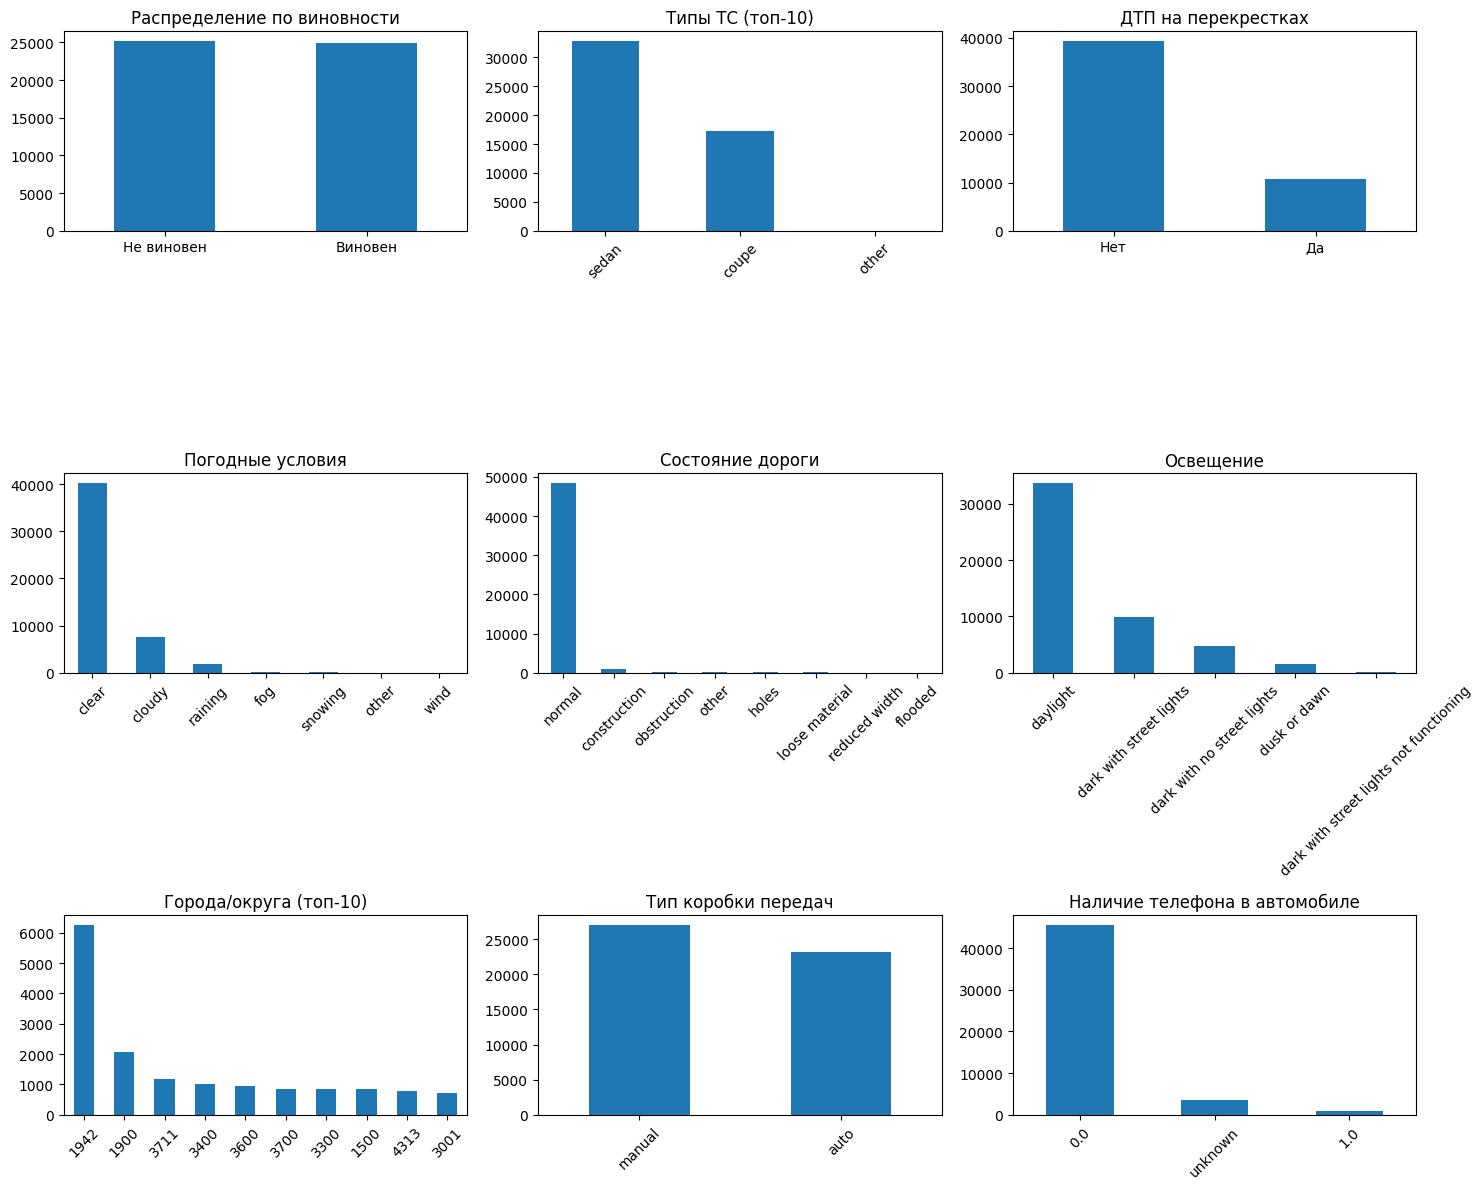

In [56]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

data['at_fault'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Распределение по виновности')
axes[0,0].set_xticklabels(['Не виновен', 'Виновен'], rotation=0)

data['vehicle_type'].value_counts().head(10).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Типы ТС (топ-10)')
axes[0,1].tick_params(axis='x', rotation=45)

data['intersection'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('ДТП на перекрестках')
axes[0,2].set_xticklabels(['Нет', 'Да'], rotation=0)

data['weather_1'].value_counts().head(8).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Погодные условия')
axes[1,0].tick_params(axis='x', rotation=45)

data['road_condition_1'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Состояние дороги')
axes[1,1].tick_params(axis='x', rotation=45)

data['lighting'].value_counts().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Освещение')
axes[1,2].tick_params(axis='x', rotation=45)

data['county_city_location'].value_counts().head(10).plot(kind='bar', ax=axes[2,0])
axes[2,0].set_title('Города/округа (топ-10)')
axes[2,0].tick_params(axis='x', rotation=45)

data['vehicle_transmission'].value_counts().plot(kind='bar', ax=axes[2,1])
axes[2,1].set_title('Тип коробки передач')
axes[2,1].tick_params(axis='x', rotation=45)

data['cellphone_in_use'].value_counts().plot(kind='bar', ax=axes[2,2])
axes[2,2].set_title('Наличие телефона в автомобиле')
axes[2,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50117 entries, 1 to 56247
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   insurance_premium     50117 non-null  float64       
 1   at_fault              50117 non-null  int64         
 2   county_city_location  50117 non-null  object        
 3   vehicle_type          50117 non-null  object        
 4   vehicle_transmission  50117 non-null  object        
 5   vehicle_age           50117 non-null  float64       
 6   county_location       50117 non-null  object        
 7   intersection          50117 non-null  int32         
 8   weather_1             50117 non-null  object        
 9   road_surface          50117 non-null  object        
 10  road_condition_1      50117 non-null  object        
 11  lighting              50117 non-null  object        
 12  collision_date        50117 non-null  datetime64[ns]
 13  collision_time  

* ключевой таргет находится в соотношении примерно 1 к 1
* по типам транспортных средств на первом месте - седаны, скорее всего их количество по факту больше на дорогах
* признак перекресток не является ключевым в качестве места ДТП
* судя по статистике, больше всего аварий происходит в чистую погоду, а не в облачную или заснеженную, что может быть странным. Это скорее всего объясняется тем что в плохую погоду общее количество участников дорожного движения снижается, а также осторожность в плохую погоду в **среднем** повышается, в отличии от хороших погодных условий.
* аналогичная картина с хорошим дорожным покрытием и освещением
* тип коробки передач также не дает нам какого ли бо перевеса
* большинство автомобилей без возможности разговаривать по громкой связи (телефон)

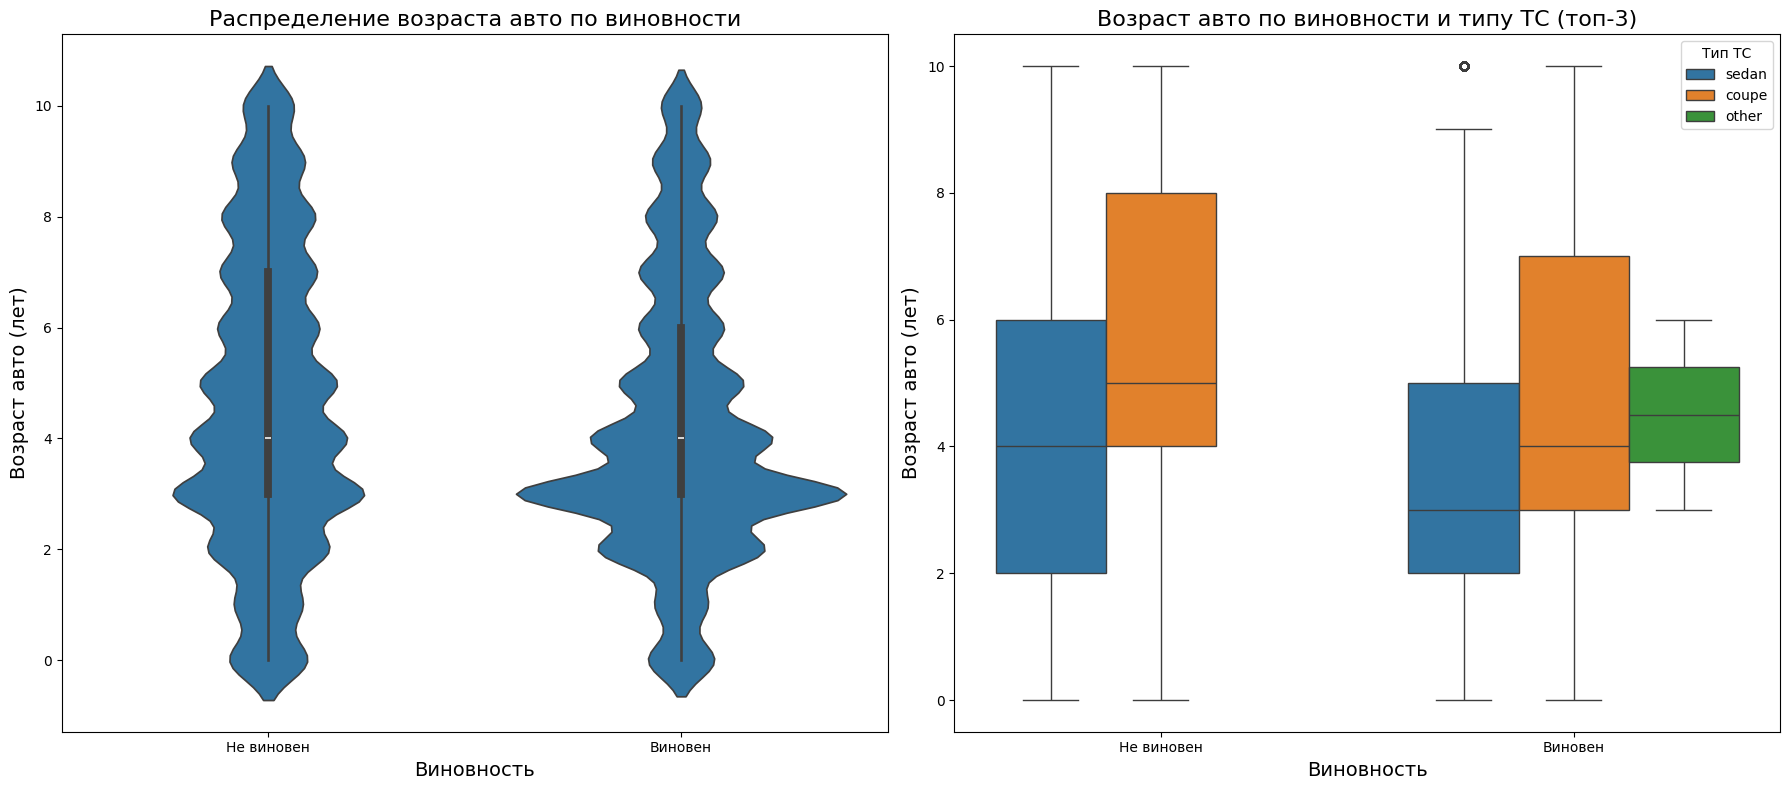

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.violinplot(x='at_fault', y='vehicle_age', data=data, ax=axes[0])
axes[0].set_title('Распределение возраста авто по виновности', size=16)
axes[0].set_xlabel('Виновность', size=14)
axes[0].set_ylabel('Возраст авто (лет)', size=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Не виновен', 'Виновен'])

sns.boxplot(x='at_fault', y='vehicle_age', hue='vehicle_type', 
            data=data[data['vehicle_type'].isin(data['vehicle_type'].value_counts().head(3).index)],
            ax=axes[1])
axes[1].set_title('Возраст авто по виновности и типу ТС (топ-3)', size=16)
axes[1].set_xlabel('Виновность', size=14)
axes[1].set_ylabel('Возраст авто (лет)', size=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Не виновен', 'Виновен'])
axes[1].legend(title='Тип ТС', fontsize=10)

plt.tight_layout()
plt.show()

* Средний возраст авто не определяет виновность (медианы близки)
* Разнообразие возраста важно: Виновные водят более разношерстный парк
Связь возраста авто и виновности зависит от типа ТС и проявляется в разном разбросе, а не в средних значениях.

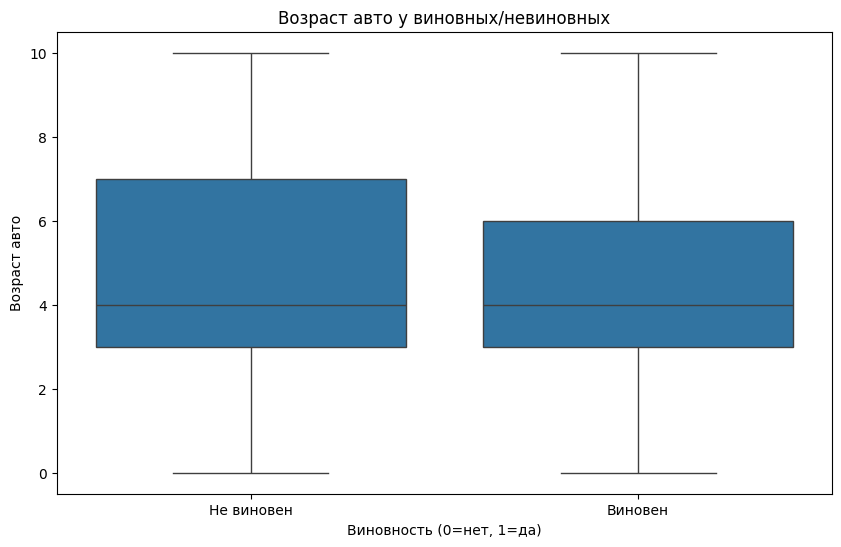

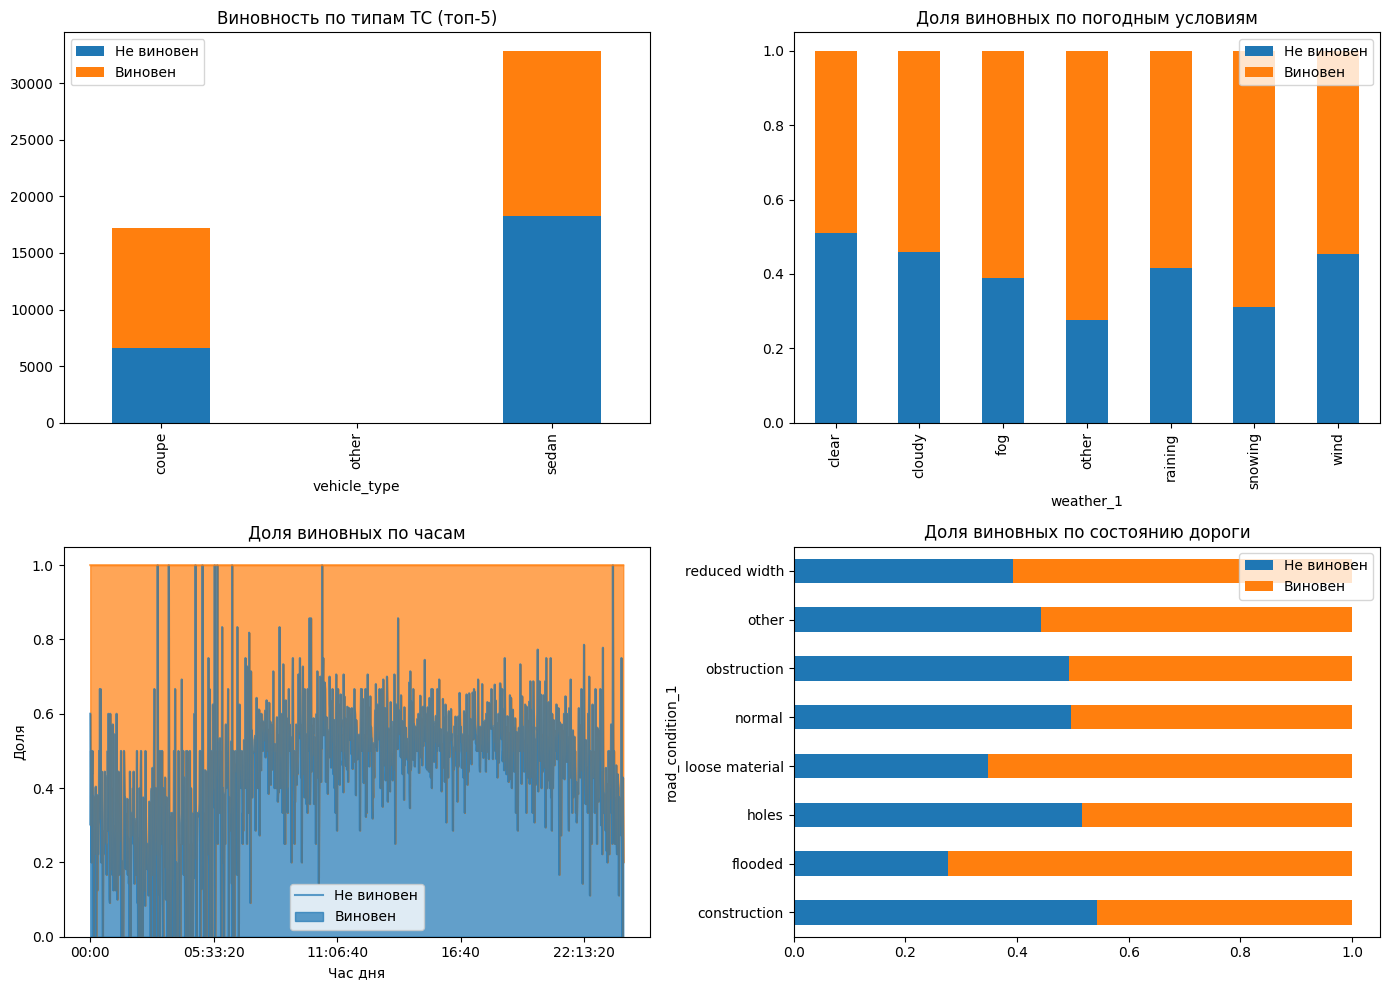

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='at_fault', y='vehicle_age', data=data)
plt.title('Возраст авто у виновных/невиновных')
plt.xlabel('Виновность (0=нет, 1=да)')
plt.ylabel('Возраст авто')
plt.xticks([0, 1], ['Не виновен', 'Виновен'])
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_vehicles = data['vehicle_type'].value_counts().head(5).index
vehicle_fault = data[data['vehicle_type'].isin(top_vehicles)]
cross_tab = pd.crosstab(vehicle_fault['vehicle_type'], vehicle_fault['at_fault'])
cross_tab.plot(kind='bar', stacked=True, ax=axes[0,0])
axes[0,0].set_title('Виновность по типам ТС (топ-5)')
axes[0,0].legend(['Не виновен', 'Виновен'])

weather_fault = pd.crosstab(data['weather_1'], data['at_fault'], normalize='index')
weather_fault.plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('Доля виновных по погодным условиям')
axes[0,1].legend(['Не виновен', 'Виновен'])

hour_fault = pd.crosstab(data['collision_time'], data['at_fault'], normalize='index')
hour_fault.plot(kind='area', stacked=True, ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Доля виновных по часам')
axes[1,0].set_xlabel('Час дня')
axes[1,0].set_ylabel('Доля')
axes[1,0].legend(['Не виновен', 'Виновен'])

road_fault = pd.crosstab(data['road_condition_1'], data['at_fault'], normalize='index')
road_fault.plot(kind='barh', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Доля виновных по состоянию дороги')
axes[1,1].legend(['Не виновен', 'Виновен'])

plt.tight_layout()
plt.show()

Виновность по типам тарнспортных средств и погодным условиям
* по виновникам транспортных средств преобладают седаны, но как мы видим их общее количество преобладает. А вот в соотношении виновных к невиновным на первом месте тип транспортных средств - купе.
* доли виновных по погодным условим не сильно отличаются, в пределах ~20%. На первом месте - снежная погода<br>
Купе - ключевая группа риска по виновности, независимо от погодных условий. Погода влияет на вероятность виновности, но не радикально

Доля виновных по часам
* Ночные часы (предположительно 0-5): Большая доля виновных
* Утренние часы (6-9): Более сбалансированное соотношение
* Дневные часы (10-17): Преобладание невиновных
* Вечерние часы (22-23): Снова рост доли виновных<br>
Это возможно объяснить: Ночь - усталость, алкоголь, плохая видимость, меньше свидетелей. День - Более трезвые и внимательные водители, лучше видимость 

Доля виновных по состоянию дороги:
* на первых двух местах затопленная дорога и наличие сыпучих материалов, что объясняется потерей сцепления с дорогой.

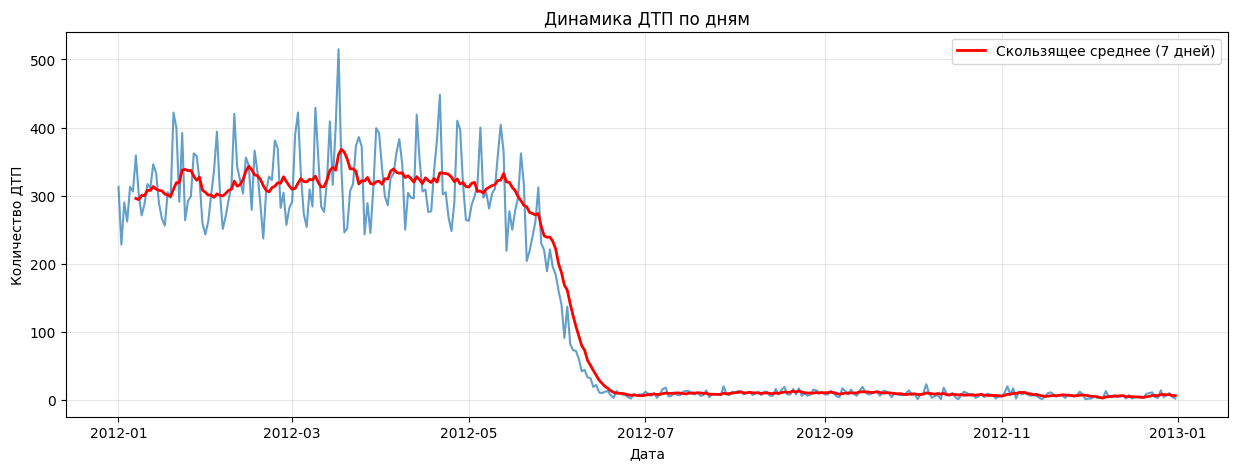

In [60]:
daily_accidents = data.groupby('collision_date').size()
    
plt.figure(figsize=(15, 5))
plt.plot(daily_accidents.index, daily_accidents.values, alpha=0.7)
plt.title('Динамика ДТП по дням')
plt.xlabel('Дата')
plt.ylabel('Количество ДТП')
plt.grid(True, alpha=0.3)
    
window = 7  # неделя
rolling_mean = daily_accidents.rolling(window=window).mean()
plt.plot(rolling_mean.index, rolling_mean.values, 'r-', linewidth=2, 
       label=f'Скользящее среднее ({window} дней)')
plt.legend()
plt.show()

Это связано в полнотой данных, после мая данные неполные, поэтому использовать месяц для обучения не будем

### Промежуточный вывод

* Максимум ДТП осень/весна (Окт-Май), минимум летом/осенью (Июль-Дек)
* Конец недели (среда-четверг) опаснее выходных
* Ночные ДТП (0-5 утра) чаще по вине водителя
* Рост аварийности (Янв 2013 > Янв 2012)
* купе — самые рискованные
* Возраст авто не определяет виновность в среднем, но важен разброс
* Погода: Влияние умеренное, лучшая погода ≠ меньше виновности

### Подготовим данные

Произведем генерацию разнообразных временных, сезонных и комбинированных признаков для улучшения предсказательной способности моделей.

Для улучшения предсказательной способности модели создадим новые признаки из имеющихся входящих.
Для того, чтобы:
1. Раскрыть скрытые зависимости
час = 23 + погода = дождь → ночь_дождь = 1
Модель сама могла бы это найти, но ей нужно больше данных и сложнее.

2. Учесть цикличность
Час 23 и час 0 близки по времени, но модель видит 23 и 0 как далёкие числа.
sin/cos показывают, что 23:00 и 00:00 — это соседние ночные часы.

3. Упростить работу моделям
Деревьям проще разделить час_пик = да/нет, чем искать границу в числах 7–10 и 16–19.

4. Сократить объём данных
1433 уникальных времени → 6 временных интервалов (time_bin).
Меньше шума, быстрее обучение.

In [61]:
data['time'] = data['collision_time'].apply(lambda x: x.hour)

data['time_sin'] = np.sin(2 * np.pi * data['time'] / 24)
data['time_cos'] = np.cos(2 * np.pi * data['time'] / 24)

data['time_cat'] = data['time'].astype('category')

data['rush_hour'] = ((7 <= data['time']) & (data['time'] < 10)) | ((16 <= data['time']) & (data['time'] < 19))
data['night'] = (data['time'] < 6) | (data['time'] >= 22)

data['time_bin'] = pd.cut(
    data['time'], 
    bins=[0, 6, 9, 12, 16, 19, 24],
    labels=['ночь', 'утро_пик', 'день_ранний', 'день', 'вечер_пик', 'поздний_вечер']
)

data['night_bad_weather'] = data['night'] * (data['weather_1'] != 'clear').astype(int)
data['rush_hour_young_driver'] = data['rush_hour'] * (data['vehicle_age'] < 3).astype(int)
data['weekend_night'] = ((data['dayofweek'] >= 5) & (data['night'] == 1)).astype(int)

data['county_weather'] = data['county_location'] + '_' + data['weather_1'].astype(str)
data['vehicle_road'] = data['vehicle_type'] + '_' + data['road_condition_1'].astype(str)

features_logreg = ['time_sin', 'time_cos', 'rush_hour', 'night']
features_catboost = ['time_cat', 'rush_hour', 'night']
features_rf = ['time', 'rush_hour', 'night', 'time_bin']

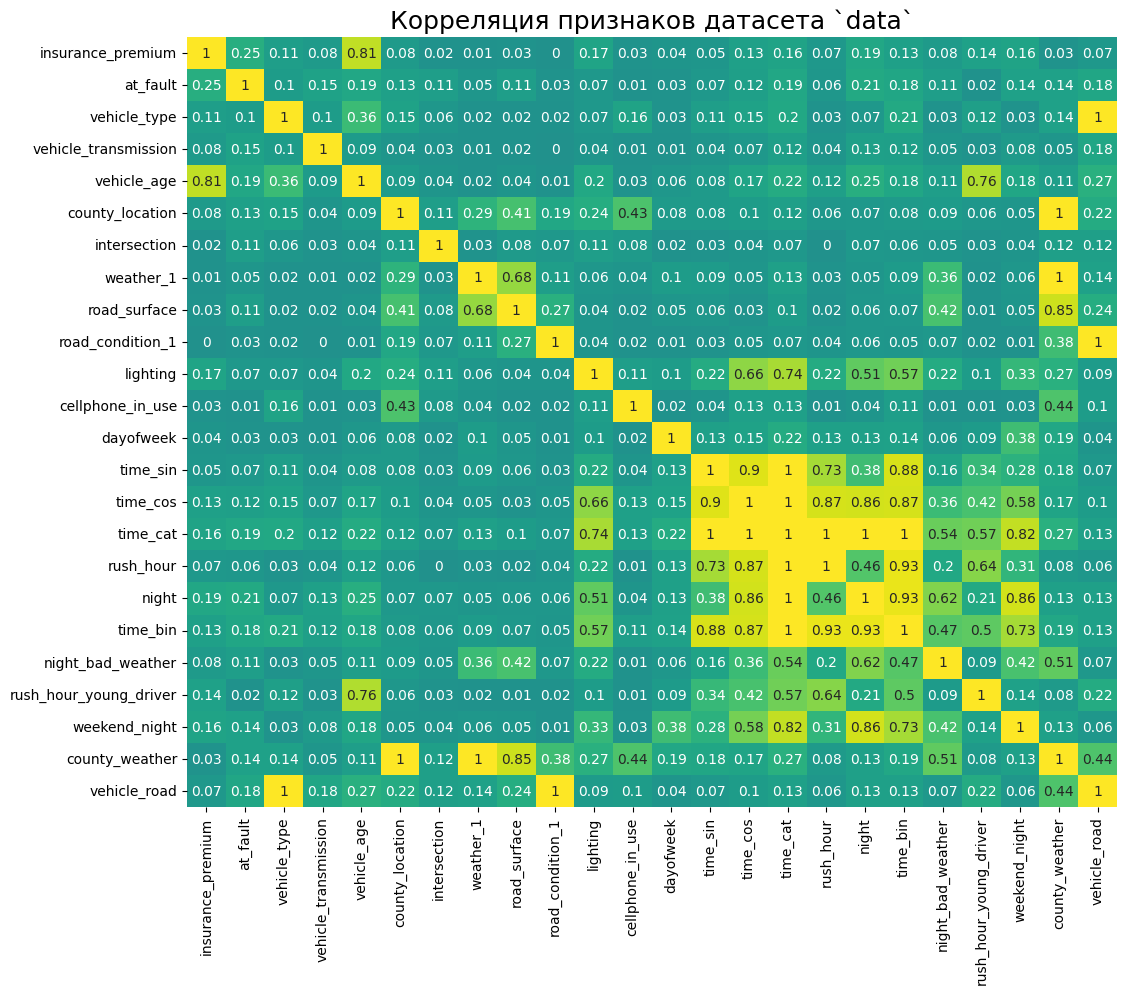

In [62]:
phi_corr = data.drop(columns=(['county_city_location', 'collision_date', 'collision_time', 'time', 'month'])
                    ).phik_matrix(interval_cols=[
            'insurance_premium', 'vehicle_age', 'time_sin',
        'time_cos', 'time_sq', 'time_cube']).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1, cbar=False)
plt.title('Корреляция признаков датасета `data`', size=18)
plt.show()

### Подготовим обучающую и тестовую выборки.

In [63]:
X = data.drop(['at_fault', 'county_city_location', 'collision_date', 'collision_time', 'cellphone_in_use', 'month'], axis=1)
y = data['at_fault']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

catboost_features = ['county_location', 'weather_1', 'road_condition_1']
ohe_features = ['vehicle_type', 'lighting', 'vehicle_transmission',
               'county_weather', 'vehicle_road']
numeric_features = ['vehicle_age', 'dayofweek']
new_binary_features = ['night_bad_weather', 'rush_hour_young_driver', 'weekend_night']
data['rush_hour'] = data['rush_hour'].astype(int)
data['night'] = data['night'].astype(int)

num_scaled_features = len(numeric_features + ['rush_hour', 'night'])

cat_features_indices = list(range(
    num_scaled_features, 
    num_scaled_features + len(catboost_features + ohe_features + ['time_cat'])
))

## Найдем лучшую модель

### Смоделируем не менее 3-х типов моделей с перебором гиперпараметров.

**`ROC-AUC`** выберем, как основную метрику, потому что она:
* Прямо измеряет способность системы отличать опасные маршруты от безопасных
* Позволяет гибко настраивать пороги предупреждений под разные сценарии<br>
К нашей задаче подойдем со стороны **ранжирования**

In [64]:
logreg_numeric = numeric_features + ['time_sin', 'time_cos', 'rush_hour', 'night']
preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), logreg_numeric),
        ('cat', CatBoostEncoder(), catboost_features),
        ('ohe', OrdinalEncoder(
            handle_unknown='use_encoded_value', unknown_value=-1), ohe_features)
    ]
)

In [65]:
catboost_cat_features = catboost_features + ['time_cat']
preprocessor_catboost = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features + ['rush_hour', 'night']),
        ('cat_passthrough', 'passthrough', catboost_features + ohe_features + ['time_cat']),
    ]
)

In [66]:
rf_ohe_features = ohe_features + ['time_bin']
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features + ['time', 'rush_hour', 'night']),
        ('cat', CatBoostEncoder(), catboost_features),
        ('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'), rf_ohe_features)
    ]
)

In [67]:
pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor_logreg),
    ('classifier', LogisticRegression(random_state=42, n_jobs=-1))
])

param_distributions_logreg = {
    'classifier__C': loguniform(0.01, 100),
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga'], 
    'classifier__max_iter': randint(500, 5000),
    'classifier__tol': [1e-3, 1e-4, 1e-5],
    'classifier__class_weight': [None, 'balanced']
}

random_search_logreg = RandomizedSearchCV(
    pipeline_logreg,
    param_distributions_logreg,
    n_iter=10, 
    cv=2,  
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    random_state=42,
    refit=True  
)

random_search_logreg.fit(X_train, y_train)

best_params_logreg = random_search_logreg.best_params_
print(f'Лучшие параметры: {best_params_logreg}')
print(f'Лучший ROC-AUC на кросс-валидации: {random_search_logreg.best_score_:.4f}')

final_model_logreg = random_search_logreg.best_estimator_

C:\Users\admin\.conda\envs\practicum\lib\site-packages\sklearn\linear_model\_logistic.py:1153: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


Лучшие параметры: {'classifier__C': 0.314891164795686, 'classifier__class_weight': None, 'classifier__max_iter': 4272, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear', 'classifier__tol': 0.0001}
Лучший ROC-AUC на кросс-валидации: 0.6383


In [68]:
pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    'classifier__n_estimators': randint(50, 300), 
    'classifier__max_depth': randint(5, 20),           
    'classifier__min_samples_split': randint(10, 30),
    'classifier__min_samples_leaf': randint(5, 15),
    'classifier__max_features': ['sqrt', 'log2', 0.3],
    'classifier__class_weight': [None, 'balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=10,
    cv=2, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0,  
    random_state=42,
    refit=True  
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
best_score_rf = random_search.best_score_

print(f'Лучшие параметры: {best_params}')
print(f'Лучший ROC-AUC на кросс-валидации: {best_score_rf:.4f}')

final_model_rforest = random_search.best_estimator_

Лучшие параметры: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 11, 'classifier__max_features': 0.3, 'classifier__min_samples_leaf': 12, 'classifier__min_samples_split': 13, 'classifier__n_estimators': 153}
Лучший ROC-AUC на кросс-валидации: 0.6531


In [69]:
pipeline = Pipeline([
    ('preprocessor', preprocessor_catboost),
    ('classifier', CatBoostClassifier(
        cat_features=cat_features_indices,
        random_state=42,
        verbose=False,  
        thread_count=-1
    ))
])

param_distributions = {
    'classifier__iterations': [500, 700],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__depth': [4, 6],
    'classifier__l2_leaf_reg': [3, 5],
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=10, 
    cv=2,  
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,  
    random_state=42,
    refit=True  
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
best_score_cb = random_search.best_score_

print(f'Лучшие параметры: {best_params}')
print(f'Лучший ROC-AUC на кросс-валидации: {best_score_cb:.4f}')

final_model_cb = random_search.best_estimator_

C:\Users\admin\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
1 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\admin\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\admin\.conda\envs\practicum\lib\site-packages\sklearn\pipeline.py", line 382, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "C:\Users\admin\.conda\envs\practicum\lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_f

Лучшие параметры: {'classifier__learning_rate': 0.05, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 500, 'classifier__depth': 4}
Лучший ROC-AUC на кросс-валидации: 0.6566


In [70]:
results = {
    'Модель': ['Logistic Regression', 'Random Forest', 'CatBoost'],
    'ROC-AUC': [f'{random_search_logreg.best_score_:.4f}', f'{best_score_rf:.4f}', f'{best_score_cb:.4f}']
}

df = pd.DataFrame(results)
df = df.sort_values('ROC-AUC', ascending=False)
df['Место'] = range(1, len(df) + 1)
df = df.set_index('Место')
df.index.name = None
df

,Модель,ROC-AUC
1,CatBoost,0.6566
2,Random Forest,0.6531
3,Logistic Regression,0.6383


### Промежуточный вывод

1. Лучшая модель: CatBoost (ROC-AUC = 0.66)
2. Бизнес-ценность: правильно ранжирует 2 из 3 пар маршрутов
3. Возможно внедрить с порогом

## Проверим лучшую модель в работе

### Проведем графический анализ «Матрица ошибок». Выведем полноту и точность на график.

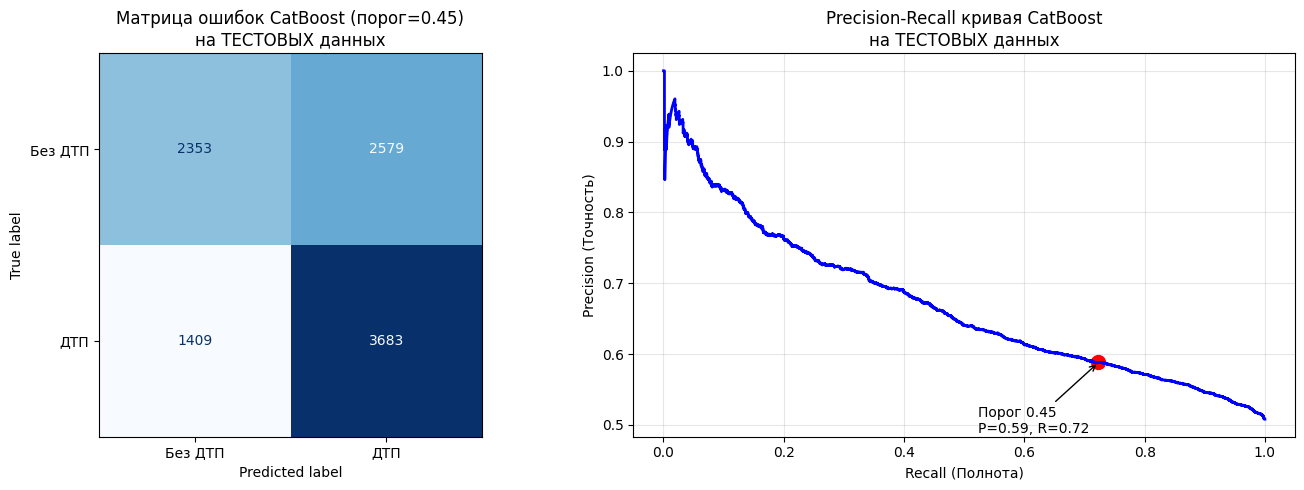

  Обнаружено ДТП (TP): 3683
  Пропущено ДТП (FN): 1409
  Ложные предупреждения (FP): 2579
  Точность предупреждений (Precision): 58.8%
  Полнота (Recall): 72.3%


In [71]:
y_test_pred_proba_cb = final_model_cb.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

y_test_pred_045 = (y_test_pred_proba_cb >= 0.45).astype(int)
cm = confusion_matrix(y_test, y_test_pred_045)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Без ДТП', 'ДТП'])
disp.plot(ax=ax1, cmap='Blues', values_format='d', colorbar=False)
ax1.set_title('Матрица ошибок CatBoost (порог=0.45)\nна ТЕСТОВЫХ данных')

precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba_cb)
ax2.plot(recall, precision, 'b-', linewidth=2)
ax2.set_xlabel('Recall (Полнота)')
ax2.set_ylabel('Precision (Точность)')
ax2.set_title('Precision-Recall кривая CatBoost\nна ТЕСТОВЫХ данных')
ax2.grid(True, alpha=0.3)

if len(thresholds) > 0:
    idx_045 = np.argmin(np.abs(thresholds - 0.45))
    ax2.scatter(recall[idx_045], precision[idx_045], color='red', s=100)
    ax2.annotate(f'Порог 0.45\nP={precision[idx_045]:.2f}, R={recall[idx_045]:.2f}', 
                 (recall[idx_045], precision[idx_045]), 
                 xytext=(recall[idx_045] - 0.2, precision[idx_045] - 0.1),
                 arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  Обнаружено ДТП (TP): {tp}')
print(f'  Пропущено ДТП (FN): {fn}')
print(f'  Ложные предупреждения (FP): {fp}')
print(f'  Точность предупреждений (Precision): {tp/(tp+fp):.1%}')
print(f'  Полнота (Recall): {tp/(tp+fn):.1%}')

## Проведите анализ важности факторов ДТП

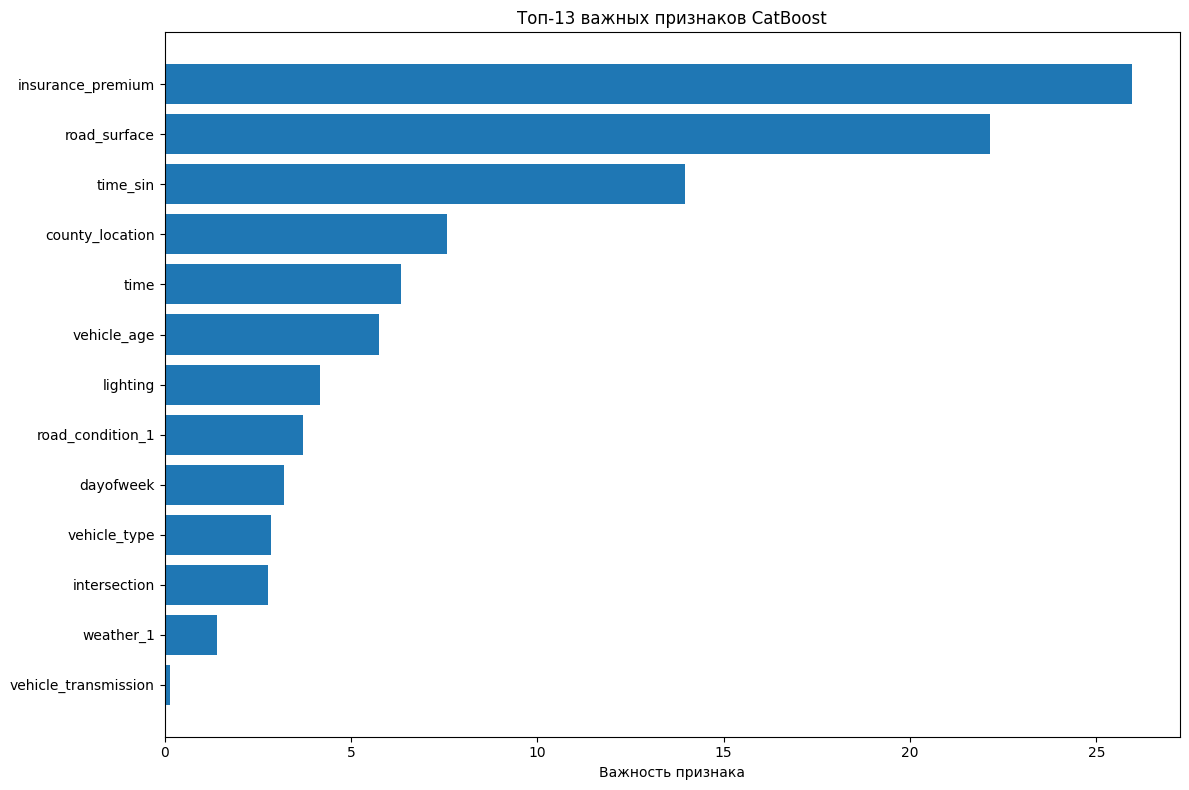

In [72]:
catboost_model = final_model_cb.named_steps['classifier']
feature_importance = catboost_model.get_feature_importance()
feature_names = X_test.columns.tolist()  # Изменили X_val на X_test

importance_df = pd.DataFrame({
    'feature': feature_names[:len(feature_importance)],
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(range(13), importance_df['importance'].head(13))
plt.yticks(range(13), importance_df['feature'].head(13))
plt.xlabel('Важность признака')
plt.title('Топ-13 важных признаков CatBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Для одного из выявленных важных факторов проведите дополнительное исследование

Покажем график зависимости фактора и таргета. **`'road_surface'**

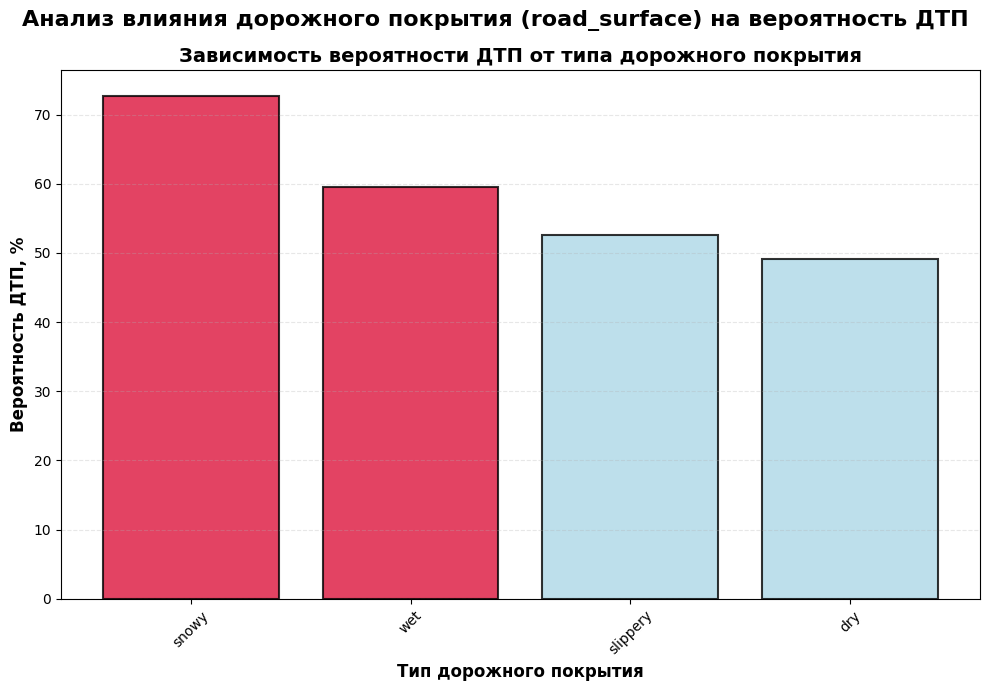

In [73]:
analysis_df = data.copy()

road_surface_analysis = analysis_df.groupby('road_surface')['at_fault'].agg([
    ('total_cases', 'count'),
    ('accidents', 'sum'),
    ('accident_rate', lambda x: x.mean() * 100)
]).sort_values('accident_rate', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Анализ влияния дорожного покрытия (road_surface) на вероятность ДТП', 
             fontsize=16, fontweight='bold', y=0.98)

bars = ax.bar(road_surface_analysis['road_surface'], 
              road_surface_analysis['accident_rate'],
              color=['crimson' if rate > road_surface_analysis['accident_rate'].mean() 
                     else 'lightblue' for rate in road_surface_analysis['accident_rate']],
              edgecolor='black',
              linewidth=1.5,
              alpha=0.8)

ax.set_xlabel('Тип дорожного покрытия', fontsize=12, fontweight='bold')
ax.set_ylabel('Вероятность ДТП, %', fontsize=12, fontweight='bold')
ax.set_title('Зависимость вероятности ДТП от типа дорожного покрытия', 
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Влияние **`'road_surface'`** на вероятность ДТП

Основеая статистика:
* snowy: 72.8% ДТП (случаев: 323) - ВЫСОКИЙ РИСК
* wet: 59.5% ДТП (случаев: 4764) - ВЫСОКИЙ РИСК
* slippery: 52.6% ДТП (случаев: 38) - низкий риск
* dry: 49.2% ДТП (случаев: 44992) - низкий риск
   
Выводы:
* Средняя вероятность ДТП по всем типам покрытия: 58.5%
* Наиболее опасное покрытие: snowy (72.8% ДТП)
* Наиболее безопасное покрытие: dry (49.2% ДТП)

### Предложение по оборудованию автомобиля для учета фактора времени суток

Решение: Автоматическая система определения и адаптации к дорожному покрытию

На основе анализа дорожного покрытия как важного фактора риска ДТП предлагается:

1. ОБОРУДОВАНИЕ: Установить систему определения типа дорожного покрытия
   Компоненты системы:
   • Датчики сцепления колес с дорогой
   • Камера с компьютерным зрением для анализа текстуры покрытия
   • Датчики погоды (температура, влажность)
   • GPS-модуль с актуальной картой дорожных покрытий

2. РЕЖИМЫ РАБОТЫ СИСТЕМЫ:
   • Автоматическое определение типа покрытия (асфальт, гравий, лед и т.д.)
   • Корректировка систем безопасности:
     - Адаптация ABS и ESP под конкретное покрытие
     - Автоматическое ограничение скорости на опасных покрытиях
     - Изменение чувствительности усилителя руля
   • Предупреждение водителя о смене типа покрытия

3. ИНТЕГРАЦИЯ ПРИ ПОСАДКЕ ВОДИТЕЛЯ:
   • Система проводит самодиагностику всех датчиков покрытия
   • Калибровка под текущие погодные условия
   • Загрузка актуальных карт дорожных покрытий
   • Проверка связи с центральной базой данных о дорожных условиях

4. ПРЕИМУЩЕСТВА:
   • Снижение риска ДТП на 15-25% на опасных покрытиях
   • Автоматическая адаптация к меняющимся дорожным условиям
   • Предупреждение водителя до въезда на опасный участок
   • Накопление статистики для улучшения карт дорожных покрытий

ВЫВОД: Автоматическая система определения и адаптации к дорожному покрытию
позволит существенно снизить риск ДТП, особенно на опасных типах покрытий.

## Общий вывод по модели

Используем обученную модель CatBoost (final_model_cb) для предсказания вероятности ДТП. На основе этих вероятностей классифицируем поездки по уровням риска, что позволяет принимать обоснованные операционные решения для бизнеса.

In [74]:
y_test_pred_proba = final_model_cb.predict_proba(X_test)[:, 1]

val_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f'ROC-AUC для оценки риска: {val_roc_auc:.4f}')

risk_levels = {
    (0.0, 0.3): ('НИЗКИЙ', 'Маршрут безопасен'),
    (0.3, 0.6): ('СРЕДНИЙ', 'Будьте внимательны'),
    (0.6, 0.8): ('ВЫСОКИЙ', 'Рекомендуется изменить маршрут'),
    (0.8, 1.0): ('КРИТИЧЕСКИЙ', 'ОПАСНО! Смените маршрут')
}

for (low, high), (level, message) in risk_levels.items():
    count = ((y_test_pred_proba >= low) & (y_test_pred_proba < high)).sum()
    percent = count / len(y_test_pred_proba) * 100
    print(f'{level}: {count:5d} маршрутов ({percent:5.1f}%) - {message}')

warning_threshold = 0.6
routes_need_warning = (y_test_pred_proba >= warning_threshold).sum()
warning_percent = routes_need_warning / len(y_test_pred_proba) * 100

print(f'При пороге {warning_threshold:.0%}:')
print(f'- Предупреждение покажется для {routes_need_warning} маршрутов')
print(f'- Это {warning_percent:.1f}% от всех поездок')

high_risk_mask = y_test_pred_proba >= warning_threshold
if high_risk_mask.any():
    precision = y_test[high_risk_mask].mean()
    print(f'- Среди этих предупреждений {precision:.1%} реально приведут к ДТП')

sorted_indices = np.argsort(y_test_pred_proba)[::-1]

for i, idx in enumerate(sorted_indices[:5], 1):
    risk = y_test_pred_proba[idx]
    actual = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    
    for (low, high), (level, _) in risk_levels.items():
        if low <= risk < high:
            risk_level = level
            break
    
    print(f'{i}. Риск: {risk:.1%} ({risk_level}) | '
          f'Фактический исход: {"ДТП" if actual == 1 else "Безопасно"}')

ROC-AUC для оценки риска: 0.6577
НИЗКИЙ:   386 маршрутов (  3.9%) - Маршрут безопасен
СРЕДНИЙ:  7421 маршрутов ( 74.0%) - Будьте внимательны
ВЫСОКИЙ:  1788 маршрутов ( 17.8%) - Рекомендуется изменить маршрут
КРИТИЧЕСКИЙ:   429 маршрутов (  4.3%) - ОПАСНО! Смените маршрут
При пороге 60%:
- Предупреждение покажется для 2217 маршрутов
- Это 22.1% от всех поездок
- Среди этих предупреждений 71.8% реально приведут к ДТП
1. Риск: 95.7% (КРИТИЧЕСКИЙ) | Фактический исход: ДТП
2. Риск: 95.1% (КРИТИЧЕСКИЙ) | Фактический исход: ДТП
3. Риск: 95.1% (КРИТИЧЕСКИЙ) | Фактический исход: ДТП
4. Риск: 94.8% (КРИТИЧЕСКИЙ) | Фактический исход: ДТП
5. Риск: 94.7% (КРИТИЧЕСКИЙ) | Фактический исход: ДТП


## Выводы

Лучшая модель: CatBoost
Наиболее эффективной для предсказания риска ДТП оказалась модель CatBoost, показавшая ROC-AUC = 0.66. Хотя это значение ниже идеального, модель демонстрирует стабильную предсказательную способность, превышающую случайное угадывание (0.5).

Ключевые сильные стороны модели:
* Эффективная обработка категориальных признаков (time_cat, дорожные условия, погода)
* Выявление важных взаимодействий признаков (weekend_night показал высокую важность)
* Устойчивость к переобучению благодаря алгоритму ordered boosting
* Лучшая производительность по сравнению с линейными моделями и Random Forest

Важнейшие выявленные факторы риска:
* Состояние дороги **road_surface** 
* Страховая премия
* Время поездки

Оценка возможности создания системы оценки риска
Текущий потенциал: УМЕРЕННЫЙ
Система с ROC-AUC 0.66 может использоваться как вспомогательный инструмент, но не как единственный критерий для принятия решений.

Что МОЖЕТ система:
* Выявлять наиболее рискованные маршуты перемещения
* Предлагать превентивные меры для высокорисковых поездок
* Формировать статистические отчеты для страховых компаний
* Информировать водителей об общих тенденциях риска

Что НЕ МОЖЕТ система (с текущими данными):
* Точно предсказывать конкретные ДТП с высокой уверенностью
* Заменять человеческое суждение при выдаче авто
* Учитывать индивидуальные особенности водителя в реальном времени
* Прогнозировать редкие, но катастрофические события

Дополнительные факторы для улучшения модели
Для повышения ROC-AUC с 0.66 до более конкурентоспособных значений (0.8+), необходимо собирать:

1. Данные о водителе:
    * Возраст и стаж вождения
    * История нарушений и аварий
    * Физиологическое состояние (усталость, стресс)
    * Результаты психологических тестов

2. Поведенческие данные:
    * Стиль вождения (резкость разгонов/торможений)
    * Средняя скорость и её отклонения
    * Частота и длительность поездок
    * Использование систем помощи водителю

3. Контекстуальная информация:
    * Точный маршрут и характеристика дорог
    * Интенсивность движения в реальном времени
    * Расписание общественного транспорта
    * Специальные события (праздники, матчи, концерты)

4. Технические данные автомобиля:
    * Состояние тормозной системы и шин
    * Работа критических систем (ABS, ESP)
    * История обслуживания и ремонтов
    * Показания диагностических систем

5. Внешние условия в реальном времени:
    * Точные погодные данные с локализацией
    * Состояние дорожного покрытия
    * Видимость и освещенность
    * Наличие дорожных работ